**Project: Image classification with 10 categories**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

# SHOW FOLDERS IN GOOGLE DRIVE

from pathlib import Path

MY_DRIVE = Path("/content/drive/MyDrive/imagenet subset")

print("Folders/files in My Drive:\n")

for item in MY_DRIVE.iterdir():
    print(item)


Folders/files in My Drive:

/content/drive/MyDrive/imagenet subset/desc.txt
/content/drive/MyDrive/imagenet subset/val
/content/drive/MyDrive/imagenet subset/train
/content/drive/MyDrive/imagenet subset/samples


In [ ]:

# DATASET PATH

from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/imagenet subset")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

print("Dataset path:", DATASET_DIR)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)

print("\nChecking paths...")
print("Dataset exists    :", DATASET_DIR.exists())
print("Train exists      :", TRAIN_DIR.exists())
print("Validation exists :", VAL_DIR.exists())


Dataset path: /content/drive/MyDrive/imagenet subset
Train path: /content/drive/MyDrive/imagenet subset/train
Validation path: /content/drive/MyDrive/imagenet subset/val

Checking paths...
Dataset exists    : True
Train exists      : True
Validation exists : True


In [ ]:
# ============================================
# CHECK TRAINING DATA
# ============================================

from pathlib import Path

class_map = {
    "n01440764": "tench",
    "n02102040": "springer",
    "n02979186": "cassette_player",
    "n03000684": "chain_saw",
    "n03028079": "church",
    "n03394916": "French_horn",
    "n03417042": "garbage_truck",
    "n03425413": "gas_pump",
    "n03445777": "golf_ball",
    "n03888257": "parachute"
}

print("TRAIN DATASET")
print("=" * 70)

total_train = 0

for folder_id, class_name in class_map.items():

    folder = TRAIN_DIR / folder_id

    if folder.exists():

        images = [
            f for f in folder.iterdir()
            if f.is_file()
        ]

        count = len(images)
        total_train += count

        print(f"{folder_id:12} | {class_name:20} | {count:6} images")

    else:
        print(f"{folder_id:12} | {class_name:20} | NOT FOUND")

print("=" * 70)
print(f"Total training images: {total_train}")


TRAIN DATASET
n01440764    | tench                |    963 images
n02102040    | springer             |    955 images
n02979186    | cassette_player      |    993 images
n03000684    | chain_saw            |    858 images
n03028079    | church               |    941 images
n03394916    | French_horn          |    956 images
n03417042    | garbage_truck        |    961 images
n03425413    | gas_pump             |    932 images
n03445777    | golf_ball            |    951 images
n03888257    | parachute            |    960 images
Total training images: 9470


In [ ]:
# ============================================
# CHECK VALIDATION DATA
# ============================================

print("VALIDATION DATASET")
print("=" * 70)

total_val = 0

for folder_id, class_name in class_map.items():

    folder = VAL_DIR / folder_id

    if folder.exists():

        images = [
            f for f in folder.iterdir()
            if f.is_file()
        ]

        count = len(images)
        total_val += count

        print(f"{folder_id:12} | {class_name:20} | {count:6} images")

    else:
        print(f"{folder_id:12} | {class_name:20} | NOT FOUND")

print("=" * 70)
print(f"Total validation images: {total_val}")


VALIDATION DATASET
n01440764    | tench                |    387 images
n02102040    | springer             |    395 images
n02979186    | cassette_player      |    357 images
n03000684    | chain_saw            |    386 images
n03028079    | church               |    409 images
n03394916    | French_horn          |    394 images
n03417042    | garbage_truck        |    389 images
n03425413    | gas_pump             |    419 images
n03445777    | golf_ball            |    399 images
n03888257    | parachute            |    390 images
Total validation images: 3925


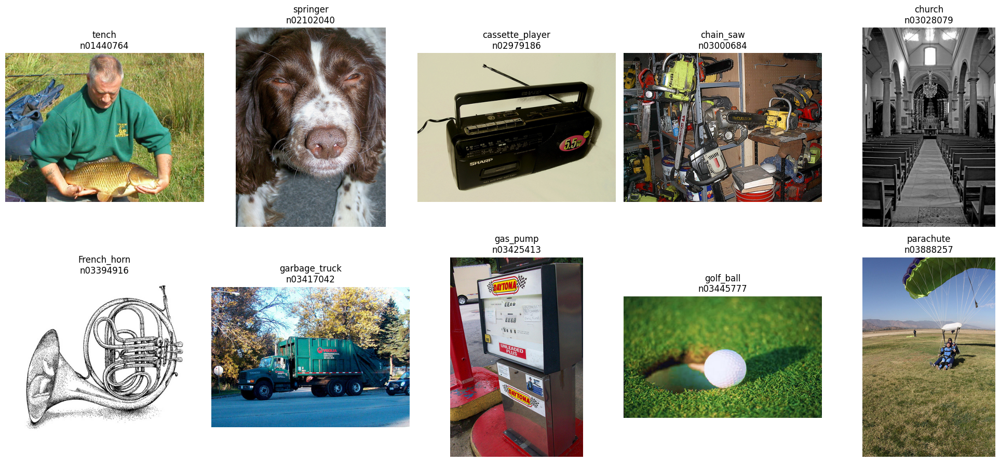

In [ ]:
# ============================================
# DISPLAY ONE IMAGE FROM EACH CLASS
# ============================================

import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for i, (folder_id, class_name) in enumerate(class_map.items()):

    folder = TRAIN_DIR / folder_id

    image_files = [
        f for f in folder.iterdir()
        if f.is_file()
    ]

    image_path = random.choice(image_files)

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(
        f"{class_name}\n{folder_id}",
        fontsize=12
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Check the Colab environment

import torch
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================
# SAVE ONE SAMPLE IMAGE FROM EACH CLASS
# ============================================

import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

SAMPLE_DIR = DATASET_DIR / "samples"
SAMPLE_DIR.mkdir(exist_ok=True)

for folder_id, class_name in class_map.items():

    folder = TRAIN_DIR / folder_id

    image_files = [
        f for f in folder.iterdir()
        if f.is_file()
    ]

    image_path = random.choice(image_files)

    image = Image.open(image_path).convert("RGB")

    # Save sample
    output_path = SAMPLE_DIR / f"{folder_id}_{class_name}.jpg"
    image.save(output_path)

    print(f"{class_name:20} -> {output_path}")

print("\nAll 10 sample images saved.")


tench                -> /content/drive/MyDrive/imagenet subset/samples/n01440764_tench.jpg
springer             -> /content/drive/MyDrive/imagenet subset/samples/n02102040_springer.jpg
cassette_player      -> /content/drive/MyDrive/imagenet subset/samples/n02979186_cassette_player.jpg
chain_saw            -> /content/drive/MyDrive/imagenet subset/samples/n03000684_chain_saw.jpg
church               -> /content/drive/MyDrive/imagenet subset/samples/n03028079_church.jpg
French_horn          -> /content/drive/MyDrive/imagenet subset/samples/n03394916_French_horn.jpg
garbage_truck        -> /content/drive/MyDrive/imagenet subset/samples/n03417042_garbage_truck.jpg
gas_pump             -> /content/drive/MyDrive/imagenet subset/samples/n03425413_gas_pump.jpg
golf_ball            -> /content/drive/MyDrive/imagenet subset/samples/n03445777_golf_ball.jpg
parachute            -> /content/drive/MyDrive/imagenet subset/samples/n03888257_parachute.jpg

All 10 sample images saved.


In [ ]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/imagenet subset")

print("Checking dataset contents...\n")

for item in DATASET_DIR.rglob("*"):
    if item.is_file():
        print(item)


Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_678.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_333.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_2119.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_4265.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_3927.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_1834.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_16515.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_906.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_1464.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_25969.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_609.JPEG
/content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_14857.JPEG
/content/drive/MyDrive/imagenet subset/train/n0297

The above output confirms that there is no Bounding box annotations information is given in the dataset.

In [ ]:
from pathlib import Path
from PIL import Image
from collections import Counter
import numpy as np

DATASET_DIR = Path("/content/drive/MyDrive/imagenet subset")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def analyze_dimensions(dataset_dir):

    dimensions = []
    corrupted = []
    grayscale = 0
    total = 0

    for class_folder in dataset_dir.iterdir():

        if not class_folder.is_dir():
            continue

        for image_path in class_folder.iterdir():

            if image_path.suffix.lower() not in image_extensions:
                continue

            total += 1

            try:
                with Image.open(image_path) as img:

                    width, height = img.size
                    dimensions.append((width, height))

                    if img.mode != "RGB":
                        grayscale += 1

            except Exception:
                corrupted.append(str(image_path))

    return dimensions, corrupted, grayscale, total


# Analyze training data
train_dims, train_corrupted, train_grayscale, train_total = \
    analyze_dimensions(TRAIN_DIR)

# Analyze validation data
val_dims, val_corrupted, val_grayscale, val_total = \
    analyze_dimensions(VAL_DIR)


# ============================================
# TRAINING RESULTS
# ============================================

print("=" * 60)
print("TRAINING IMAGE DIMENSIONS")
print("=" * 60)

widths = [w for w, h in train_dims]
heights = [h for w, h in train_dims]

print("Total images:", train_total)
print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Average width:", round(np.mean(widths), 2))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))
print("Average height:", round(np.mean(heights), 2))

print("Unique dimensions:", len(set(train_dims)))
print("Non-RGB images:", train_grayscale)
print("Corrupted images:", len(train_corrupted))


# Most common dimensions
dimension_counts = Counter(train_dims)

print("\nTop 15 most common dimensions:")

for dimension, count in dimension_counts.most_common(15):
    print(f"{dimension[0]} x {dimension[1]} : {count} images")


# ============================================
# VALIDATION RESULTS
# ============================================

print("\n" + "=" * 60)
print("VALIDATION IMAGE DIMENSIONS")
print("=" * 60)

widths = [w for w, h in val_dims]
heights = [h for w, h in val_dims]

print("Total images:", val_total)
print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Average width:", round(np.mean(widths), 2))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))
print("Average height:", round(np.mean(heights), 2))

print("Unique dimensions:", len(set(val_dims)))
print("Non-RGB images:", val_grayscale)
print("Corrupted images:", len(val_corrupted))


print("\nTop 15 most common dimensions:")

dimension_counts = Counter(val_dims)

for dimension, count in dimension_counts.most_common(15):
    print(f"{dimension[0]} x {dimension[1]} : {count} images")


TRAINING IMAGE DIMENSIONS
Total images: 9470
Minimum width: 50
Maximum width: 4288
Average width: 471.6
Minimum height: 27
Maximum height: 4368
Average height: 407.77
Unique dimensions: 2296
Non-RGB images: 173
Corrupted images: 0

Top 15 most common dimensions:
500 x 375 : 2175 images
500 x 333 : 818 images
375 x 500 : 717 images
333 x 500 : 309 images
500 x 334 : 207 images
640 x 480 : 126 images
500 x 332 : 91 images
500 x 500 : 88 images
400 x 300 : 78 images
500 x 335 : 75 images
334 x 500 : 67 images
500 x 400 : 53 images
500 x 374 : 46 images
332 x 500 : 45 images
200 x 150 : 44 images

VALIDATION IMAGE DIMENSIONS
Total images: 3925
Minimum width: 50
Maximum width: 4214
Average width: 468.83
Minimum height: 32
Maximum height: 3521
Average height: 407.07
Unique dimensions: 1102
Non-RGB images: 69
Corrupted images: 0

Top 15 most common dimensions:
500 x 375 : 960 images
500 x 333 : 356 images
375 x 500 : 324 images
333 x 500 : 123 images
500 x 334 : 69 images
640 x 480 : 41 image

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


**Create preprocessing transformations**

In [ ]:
# ============================================
# IMAGE PREPROCESSING
# ============================================

IMG_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transformations
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Preprocessing pipeline created successfully.")
print("Target image size:", IMG_SIZE, "x", IMG_SIZE)


Preprocessing pipeline created successfully.
Target image size: 224 x 224


**Create the datasets**

In [ ]:
# ============================================
# CREATE TRAINING AND VALIDATION DATASETS
# ============================================

from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))

print("\nClass mapping:")
for class_index, class_name in enumerate(train_dataset.classes):
    print(f"{class_index} -> {class_name}")


DATASET INFORMATION
Training images   : 9470
Validation images : 3925

Class mapping:
0 -> n01440764
1 -> n02102040
2 -> n02979186
3 -> n03000684
4 -> n03028079
5 -> n03394916
6 -> n03417042
7 -> n03425413
8 -> n03445777
9 -> n03888257


**Create DataLoaders**

In [ ]:
# ============================================
# CREATE DATALOADERS
# ============================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 60)
print("DATALOADER INFORMATION")
print("=" * 60)

print("Batch size          :", BATCH_SIZE)
print("Training batches    :", len(train_loader))
print("Validation batches  :", len(val_loader))


DATALOADER INFORMATION
Batch size          : 32
Training batches    : 296
Validation batches  : 123


**Verify the processed image tensors**

In [ ]:
# ============================================
# VERIFY PROCESSED IMAGE TENSORS
# ============================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("PROCESSED IMAGE VERIFICATION")
print("=" * 60)

print("Batch shape       :", images.shape)
print("Labels shape      :", labels.shape)
print("Data type         :", images.dtype)
print("Minimum value     :", images.min().item())
print("Maximum value     :", images.max().item())


PROCESSED IMAGE VERIFICATION
Batch shape       : torch.Size([32, 3, 224, 224])
Labels shape      : torch.Size([32])
Data type         : torch.float32
Minimum value     : -2.1179039478302
Maximum value     : 2.640000104904175


**Visually verify the preprocessing**

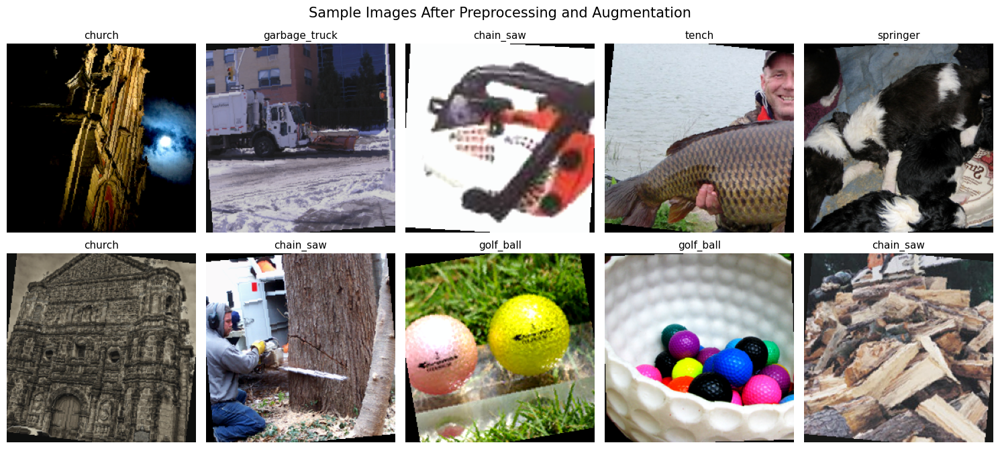

In [ ]:
# ============================================
# VISUALIZE PREPROCESSED TRAINING IMAGES
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# ImageNet normalization values
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(10):

    # Convert from Tensor [C,H,W] to NumPy [H,W,C]
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    image = image * std + mean

    # Keep pixel values between 0 and 1
    image = np.clip(image, 0, 1)

    # Get class label
    label = labels[i].item()
    class_id = train_dataset.classes[label]

    # Convert ImageNet ID to your class name
    class_name = class_map[class_id]

    axes[i].imshow(image)
    axes[i].set_title(class_name, fontsize=11)
    axes[i].axis("off")

plt.suptitle(
    "Sample Images After Preprocessing and Augmentation",
    fontsize=15
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# CHECK LOW-RESOLUTION IMAGES
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

low_res_images = []

for class_id, class_name in class_map.items():
    folder = TRAIN_DIR / class_id

    for image_path in folder.iterdir():
        if image_path.is_file():
            try:
                with Image.open(image_path) as img:
                    width, height = img.size

                    # Find very small images
                    if width < 100 or height < 100:
                        low_res_images.append(
                            (image_path, width, height, class_name)
                        )

            except Exception:
                pass

print("Number of very low-resolution images:",
      len(low_res_images))

for item in low_res_images[:10]:
    print(
        item[3],
        "->",
        item[1], "x", item[2],
        "->",
        item[0]
    )


Number of very low-resolution images: 138
tench -> 75 x 56 -> /content/drive/MyDrive/imagenet subset/train/n01440764/n01440764_107.JPEG
tench -> 130 x 97 -> /content/drive/MyDrive/imagenet subset/train/n01440764/n01440764_1379.JPEG
tench -> 100 x 70 -> /content/drive/MyDrive/imagenet subset/train/n01440764/n01440764_297.JPEG
tench -> 120 x 79 -> /content/drive/MyDrive/imagenet subset/train/n01440764/n01440764_5785.JPEG
springer -> 130 x 98 -> /content/drive/MyDrive/imagenet subset/train/n02102040/n02102040_114.JPEG
springer -> 140 x 93 -> /content/drive/MyDrive/imagenet subset/train/n02102040/n02102040_1129.JPEG
cassette_player -> 145 x 87 -> /content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_26405.JPEG
cassette_player -> 90 x 90 -> /content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_8956.JPEG
cassette_player -> 90 x 90 -> /content/drive/MyDrive/imagenet subset/train/n02979186/n02979186_10036.JPEG
cassette_player -> 135 x 95 -> /content/drive/MyDrive/imagenet

**Visualize low-resolution images**

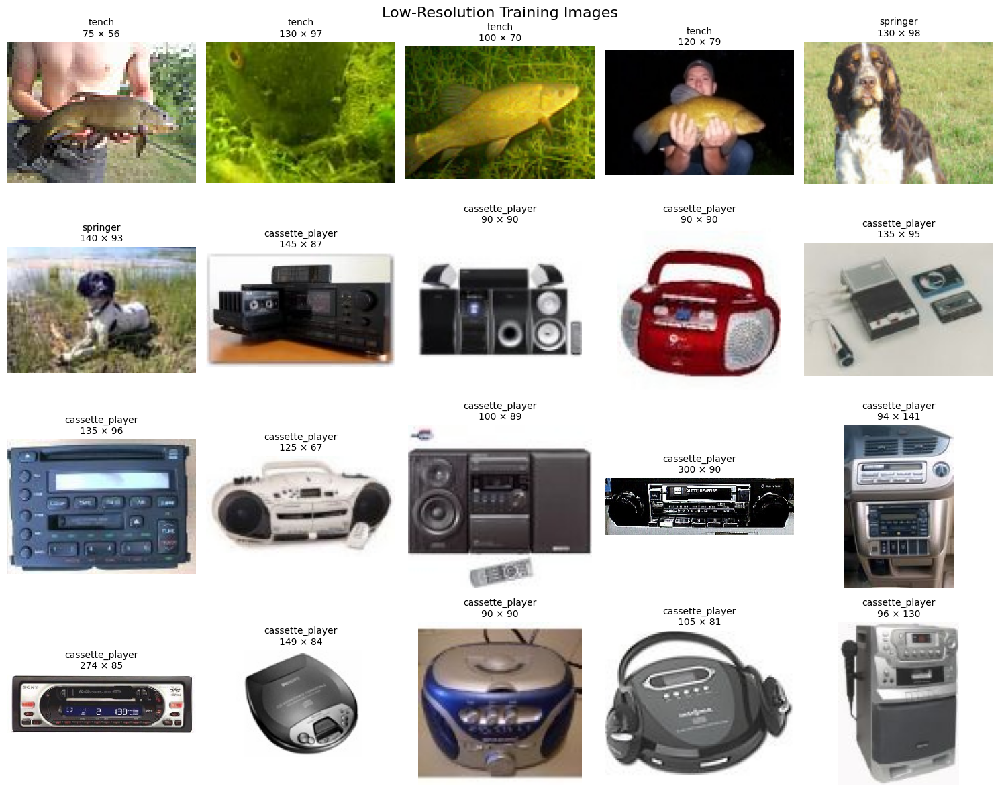

In [ ]:
# ============================================
# VISUALIZE LOW-RESOLUTION IMAGES
# ============================================

import matplotlib.pyplot as plt
from PIL import Image

# Display first 20 low-resolution images
num_images = min(20, len(low_res_images))

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i in range(num_images):

    image_path, width, height, class_name = low_res_images[i]

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(
        f"{class_name}\n{width} × {height}",
        fontsize=10
    )
    axes[i].axis("off")

plt.suptitle(
    "Low-Resolution Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()


use resize + center padding for classification. This preserves the complete image/object while still giving the model a consistent 224 × 224 input.

**Update the preprocessing pipeline**

In [ ]:
# ============================================
# UPDATED IMAGE PREPROCESSING
# ============================================

import torchvision.transforms as transforms

IMG_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Updated preprocessing pipeline created.")
print("Target size:", IMG_SIZE, "x", IMG_SIZE)


Updated preprocessing pipeline created.
Target size: 224 x 224


why we are using direct resize now?

Because we need to keep this project straightforward and consistent.

The images have many different aspect ratios, but your objects are still recognizable. For a first classification model, 224 × 224 is a standard and practical input size.

**Re-create the datasets**

In [ ]:
# ============================================
# RECREATE DATASETS WITH UPDATED TRANSFORMS
# ============================================

train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))


Training images   : 9470
Validation images : 3925


**Recreate Dataloaders**

In [ ]:
# ============================================
# RECREATE DATALOADERS
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))


Training batches   : 296
Validation batches : 123


In [ ]:
images, labels = next(iter(train_loader))

print("Batch shape :", images.shape)
print("Labels shape:", labels.shape)


Batch shape : torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [ ]:
# ============================================
# VERIFY UPDATED PREPROCESSING
# ============================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("UPDATED PREPROCESSING VERIFICATION")
print("=" * 60)

print("Batch shape  :", images.shape)
print("Labels shape :", labels.shape)
print("Data type    :", images.dtype)


UPDATED PREPROCESSING VERIFICATION
Batch shape  : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Data type    : torch.float32


In [ ]:
# ============================================
# CHECK GPU
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU not available. Training will use CPU.")


Device: cuda
GPU: Tesla T4
CUDA version: 12.8


**Build the Image Classification Model**

**ResNet18**

In [ ]:
# ============================================
# LOAD PRETRAINED RESNET18
# ============================================

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print("Pretrained ResNet18 loaded successfully.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


Pretrained ResNet18 loaded successfully.


In [ ]:
# ============================================
# CHECK FINAL CLASSIFICATION LAYER
# ============================================

print("Original final layer:")
print(model.fc)


Original final layer:
Linear(in_features=512, out_features=1000, bias=True)


**Modify ResNet18 for 10 class**

In [ ]:
# ============================================
# MODIFY RESNET18 FOR 10 CLASSES
# ============================================

NUM_CLASSES = 10

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

print("Updated final layer:")
print(model.fc)


Updated final layer:
Linear(in_features=512, out_features=10, bias=True)


In [ ]:
# ============================================
# MOVE MODEL TO GPU
# ============================================

model = model.to(device)

print("Model is using:", device)


Model is using: cuda


In [ ]:
# ============================================
# VERIFY MODEL DEVICE
# ============================================

print("Model device:", next(model.parameters()).device)


Model device: cuda:0


**Loss Function and optimizer**

In [ ]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

# Number of epochs
NUM_EPOCHS = 10

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", 0.0001)
print("Weight decay  :", 1e-4)
print("Epochs        :", NUM_EPOCHS)
print("Device        :", device)


TRAINING CONFIGURATION
Loss function : CrossEntropyLoss()
Optimizer     : Adam
Learning rate : 0.0001
Weight decay  : 0.0001
Epochs        : 10
Device        : cuda


**Train the model**

In [ ]:
# ============================================
# TRAINING AND VALIDATION LOOP
# ============================================

import time
import copy
import torch

# Store training history
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

print("=" * 70)
print("STARTING MODEL TRAINING")
print("=" * 70)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ----------------------------------------
    # TRAINING
    # ----------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_accuracy = 100 * correct / total

    # ----------------------------------------
    # VALIDATION
    # ----------------------------------------

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Move data to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Calculate validation loss
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / val_total
    epoch_val_accuracy = 100 * val_correct / val_total

    # Store history
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # Update learning rate
    scheduler.step(epoch_val_loss)

    # Save best model
    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy
        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            "/content/best_resnet18.pth"
        )

        best_marker = "BEST"

    else:
        best_marker = ""

    # Epoch time
    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}% | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print("Best model saved to:")
print("/content/best_resnet18.pth")


STARTING MODEL TRAINING
Epoch [01/10] | Train Loss: 0.2688 | Train Acc: 92.56% | Val Loss: 0.1095 | Val Acc: 96.61% | Time: 119.6sBEST
Epoch [02/10] | Train Loss: 0.0896 | Train Acc: 97.39% | Val Loss: 0.1069 | Val Acc: 96.61% | Time: 115.0s
Epoch [03/10] | Train Loss: 0.0630 | Train Acc: 98.14% | Val Loss: 0.1200 | Val Acc: 96.25% | Time: 113.8s
Epoch [04/10] | Train Loss: 0.0491 | Train Acc: 98.60% | Val Loss: 0.0997 | Val Acc: 96.66% | Time: 114.3sBEST
Epoch [05/10] | Train Loss: 0.0341 | Train Acc: 99.09% | Val Loss: 0.0929 | Val Acc: 96.89% | Time: 113.9sBEST
Epoch [06/10] | Train Loss: 0.0242 | Train Acc: 99.33% | Val Loss: 0.1068 | Val Acc: 96.71% | Time: 117.1s
Epoch [07/10] | Train Loss: 0.0287 | Train Acc: 99.24% | Val Loss: 0.1211 | Val Acc: 96.33% | Time: 117.1s
Epoch [08/10] | Train Loss: 0.0327 | Train Acc: 98.89% | Val Loss: 0.1312 | Val Acc: 95.90% | Time: 115.5s
Epoch [09/10] | Train Loss: 0.0186 | Train Acc: 99.57% | Val Loss: 0.0905 | Val Acc: 97.12% | Time: 116.1sBE

In [ ]:
import torch

# Load best weights
model.load_state_dict(
    torch.load(
        "/content/best_resnet18.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best ResNet-18 model loaded successfully.")


Best ResNet-18 model loaded successfully.


In [ ]:
# ============================================
# CLASS NAMES
# ============================================

class_names = list(class_map.values())

print("Class names:")
for i, name in enumerate(class_names):
    print(i, "->", name)


Class names:
0 -> tench
1 -> springer
2 -> cassette_player
3 -> chain_saw
4 -> church
5 -> French_horn
6 -> garbage_truck
7 -> gas_pump
8 -> golf_ball
9 -> parachute


**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
import torch

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


                 precision    recall  f1-score   support

          tench     0.9922    0.9819    0.9870       387
       springer     1.0000    0.9797    0.9898       395
cassette_player     0.9612    0.9720    0.9666       357
      chain_saw     0.9456    0.9456    0.9456       386
         church     0.9950    0.9829    0.9889       409
    French_horn     0.9483    0.9772    0.9625       394
  garbage_truck     0.9842    0.9614    0.9727       389
       gas_pump     0.9614    0.9523    0.9568       419
      golf_ball     0.9778    0.9950    0.9863       399
      parachute     0.9698    0.9872    0.9784       390

       accuracy                         0.9735      3925
      macro avg     0.9736    0.9735    0.9735      3925
   weighted avg     0.9737    0.9735    0.9735      3925



**Confusion Matrix**

[[380   0   0   1   0   3   0   0   2   1]
 [  0 387   0   4   0   2   0   0   1   1]
 [  0   0 347   3   0   3   0   2   1   1]
 [  1   0   5 365   0   4   2   3   3   3]
 [  0   0   1   0 402   2   1   1   0   2]
 [  1   0   2   3   0 385   0   1   1   1]
 [  0   0   0   4   1   1 374   8   0   1]
 [  0   0   6   4   1   4   3 399   1   1]
 [  1   0   0   0   0   0   0   0 397   1]
 [  0   0   0   2   0   2   0   1   0 385]]


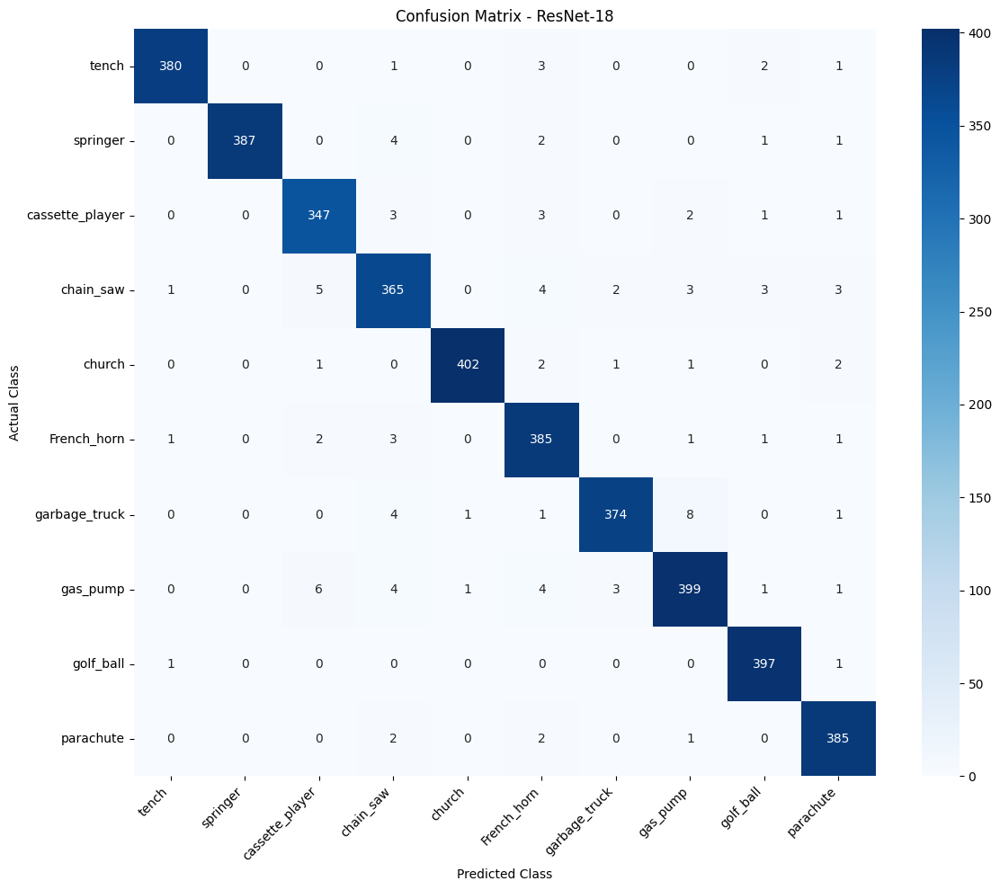

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - ResNet-18")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


The trained ResNet-18 deep learning model was evaluated on a validation dataset containing 3,925 images belonging to 10 object categories. The model achieved an overall validation accuracy of 97.35%, demonstrating strong performance in recognizing the target object categories.

**Classification Report**

The detailed classification report is presented below:



In [ ]:
import pandas as pd

data = {
    "Class": [
        "Tench", "Springer", "Cassette Player", "Chain Saw", "Church",
        "French Horn", "Garbage Truck", "Gas Pump", "Golf Ball", "Parachute",
        "Accuracy", "Macro Average", "Weighted Average"
    ],
    "Precision": [
        "99.22%", "100.00%", "96.12%", "94.56%", "99.50%",
        "94.83%", "98.42%", "96.14%", "97.78%", "96.98%",
        "—", "97.36%", "97.37%"
    ],
    "Recall": [
        "98.19%", "97.97%", "97.20%", "94.56%", "98.29%",
        "97.72%", "96.14%", "95.23%", "99.50%", "98.72%",
        "—", "97.35%", "97.35%"
    ],
    "F1-Score": [
        "98.70%", "98.98%", "96.66%", "94.56%", "98.89%",
        "96.25%", "97.27%", "95.68%", "98.63%", "97.84%",
        "97.35%", "97.35%", "97.35%"
    ],
    "Support": [
        387, 395, 357, 386, 409,
        394, 389, 419, 399, 390,
        3925, 3925, 3925
    ]
}

df = pd.DataFrame(data)
df

def highlight_rows(row):
    styles = [''] * len(row)
    if row.name in [10, 11, 12]:
        styles[3] = 'background-color: #d9ead3; font-weight: bold'
        styles[4] = 'background-color: #d9ead3; font-weight: bold'
    return styles

df.style.apply(highlight_rows, axis=1)


,Class,Precision,Recall,F1-Score,Support
0,Tench,99.22%,98.19%,98.70%,387
1,Springer,100.00%,97.97%,98.98%,395
2,Cassette Player,96.12%,97.20%,96.66%,357
3,Chain Saw,94.56%,94.56%,94.56%,386
4,Church,99.50%,98.29%,98.89%,409
5,French Horn,94.83%,97.72%,96.25%,394
6,Garbage Truck,98.42%,96.14%,97.27%,389
7,Gas Pump,96.14%,95.23%,95.68%,419
8,Golf Ball,97.78%,99.50%,98.63%,399
9,Parachute,96.98%,98.72%,97.84%,390


**Classification Performance Analysis**


The classification report shows that the model performs consistently well across all ten categories. The overall accuracy of 97.35% indicates that the model correctly classified approximately 97 out of every 100 validation images.

The **Springer category** achieved the highest precision of 100.00%, meaning that every image predicted as Springer was actually a Springer image. It also achieved an F1-score of 98.98%, making it one of the strongest-performing categories.

The **Golf Ball** category achieved the highest recall of 99.50%, with 397 out of 399 validation images correctly identified. The **Church and Tench categories** also performed exceptionally well, with F1-scores of 98.89% and 98.70%, respectively.

The lowest F1-score was obtained for **Chain Saw** at 94.56%, followed by **Gas Pump** at 95.68%. Although these categories had relatively more classification errors, their performance remained above 94%, indicating that the model was still able to classify them reliably.

The macro-average F1-score of 97.35% and weighted-average F1-score of 97.35% are almost identical. This indicates that the model's performance is well balanced across the ten classes and is not heavily dependent on any particular category.



**Confusion Matrix**

The confusion matrix obtained from the validation dataset is:



In [ ]:
import pandas as pd

classes = [
    "Tench", "Springer", "Cassette Player", "Chain Saw", "Church",
    "French Horn", "Garbage Truck", "Gas Pump", "Golf Ball", "Parachute"
]

cm = [
    [380, 0, 0, 1, 0, 3, 0, 0, 2, 1],
    [0, 387, 0, 4, 0, 2, 0, 0, 1, 1],
    [0, 0, 347, 3, 0, 3, 0, 2, 1, 1],
    [1, 0, 5, 365, 0, 4, 2, 3, 3, 3],
    [0, 0, 1, 0, 402, 2, 1, 1, 0, 2],
    [1, 0, 2, 3, 0, 385, 0, 1, 1, 1],
    [0, 0, 0, 4, 1, 1, 374, 8, 0, 1],
    [0, 0, 6, 4, 1, 4, 3, 399, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 397, 1],
    [0, 0, 0, 2, 0, 2, 0, 1, 0, 385]
]

cm_df = pd.DataFrame(cm, index=classes, columns=classes)

cm_df.index.name = "Actual \\ Predicted"

cm_df


,Tench,Springer,Cassette Player,Chain Saw,Church,French Horn,Garbage Truck,Gas Pump,Golf Ball,Parachute
Actual \ Predicted,,,,,,,,,,
Tench,380,0,0,1,0,3,0,0,2,1
Springer,0,387,0,4,0,2,0,0,1,1
Cassette Player,0,0,347,3,0,3,0,2,1,1
Chain Saw,1,0,5,365,0,4,2,3,3,3
Church,0,0,1,0,402,2,1,1,0,2
French Horn,1,0,2,3,0,385,0,1,1,1
Garbage Truck,0,0,0,4,1,1,374,8,0,1
Gas Pump,0,0,6,4,1,4,3,399,1,1
Golf Ball,1,0,0,0,0,0,0,0,397,1


**Confusion Matrix Analysis**

The confusion matrix demonstrates a strong concentration of predictions along the main diagonal. The diagonal values represent correctly classified images, while the off-diagonal values represent misclassifications.

The model correctly classified 380 of 387 Tench images, 387 of 395 Springer images, 347 of 357 Cassette Player images, and 365 of 386 Chain Saw images. Similarly, it correctly classified 402 of 409 Church images, 385 of 394 French Horn images, and 374 of 389 Garbage Truck images.

The Gas Pump category had 399 correct predictions out of 419 images, while Golf Ball had 397 correct predictions out of 399 images, making Golf Ball one of the most accurately recognized categories. The Parachute category also achieved strong performance with 385 correct predictions out of 390 images.

The largest number of errors occurred in the Chain Saw and Gas Pump categories. Chain Saw had 21 misclassified images. Its most notable confusion was with Cassette Player, where 5 Chain Saw images were incorrectly classified. Other Chain Saw images were predicted as French Horn, Gas Pump, Golf Ball, and Parachute.

Gas Pump had 20 incorrect predictions. The main confusion involved Cassette Player, with 6 Gas Pump images incorrectly classified as Cassette Player. Additional errors occurred with Chain Saw, French Horn, and Garbage Truck.

Overall, there were only 104 incorrect predictions out of 3,925 validation images, while 3,821 images were correctly classified. This corresponds to the overall validation accuracy of 97.35%.

**Overall Conclusion**

The classification report and confusion matrix together demonstrate that the ResNet-18 model provides highly effective and consistent performance across all ten object categories. The model achieved 97.35% validation accuracy, with macro and weighted F1-scores also approximately 97.35%.

The strong diagonal pattern in the confusion matrix confirms that the model correctly distinguishes most of the ten categories. Although Chain Saw and Gas Pump show slightly higher confusion than the other classes, their F1-scores remain above 94%.

Therefore, the developed ResNet-18 model can be considered a strong image classification solution for the given ten-category dataset. The trained model can subsequently be used for inference on previously unseen images.

Note: This evaluation represents image classification. Since the original project objective also mentions object detection, a separate object-detection model with bounding-box annotations would be required to identify both the object category and its location within an image.

**CNN Model**

In [ ]:
# ============================================
# CNN SETUP
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Dataset paths
DATASET_DIR = Path(
    "/content/drive/MyDrive/imagenet subset"
)

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

# Class mapping
class_map = {
    "n01440764": "tench",
    "n02102040": "springer",
    "n02979186": "cassette_player",
    "n03000684": "chain_saw",
    "n03028079": "church",
    "n03394916": "French_horn",
    "n03417042": "garbage_truck",
    "n03425413": "gas_pump",
    "n03445777": "golf_ball",
    "n03888257": "parachute"
}

print("Dataset exists:", DATASET_DIR.exists())
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())


Device: cuda
Dataset exists: True
Train exists: True
Val exists: True


In [ ]:
# ============================================
# DEFINE DEVICE
# ============================================

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Using CPU.")


Using device: cuda
GPU: Tesla T4


In [ ]:
# ============================================
# CNN IMAGE CLASSIFICATION
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from PIL import Image

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0+cu128
Device: cuda


**Load and preprocess the images**

In [ ]:
# ============================================
#  IMAGE PREPROCESSING
# ============================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing completed.")


Image preprocessing completed.


**Load the training and validation datasets**

In [ ]:
# ============================================
#  LOAD DATASETS
# ============================================

train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=str(VAL_DIR),
    transform=val_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)

print("\nClass indices:")
print(train_dataset.class_to_idx)


Training images: 9470
Validation images: 3925

Classes:
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']

Class indices:
{'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}


In [ ]:
# ============================================
#  CLASS NAMES
# ============================================

class_names = [
    class_map[x]
    for x in train_dataset.classes
]

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

for i, name in enumerate(class_names):
    print(f"{i} -> {name}")


Number of classes: 10
0 -> tench
1 -> springer
2 -> cassette_player
3 -> chain_saw
4 -> church
5 -> French_horn
6 -> garbage_truck
7 -> gas_pump
8 -> golf_ball
9 -> parachute


**Create DataLoaders**

In [ ]:
# ============================================
#  DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Batch size: 32
Training batches: 296
Validation batches: 123


**Create the CNN**

In [ ]:
# ============================================
# CNN MODEL
# ============================================

class CNNClassifier(nn.Module):

    def __init__(self, num_classes=10):

        super(CNNClassifier, self).__init__()

        self.features = nn.Sequential(

            # ==================================
            # BLOCK 1
            # ==================================

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            # ==================================
            # BLOCK 2
            # ==================================

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            # ==================================
            # BLOCK 3
            # ==================================

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            # ==================================
            # BLOCK 4
            # ==================================

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Converts feature maps to 1x1
        self.avgpool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # ==================================
        # CLASSIFIER
        # ==================================

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = self.classifier(x)

        return x


**Create  the CNN model**

In [ ]:
# ============================================
#  CREATE CNN
# ============================================

cnn_model = CNNClassifier(
    num_classes=NUM_CLASSES
)

cnn_model = cnn_model.to(device)

print(cnn_model)


CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1

In [ ]:
# ============================================
#  MODEL PARAMETERS
# ============================================

total_params = sum(
    p.numel()
    for p in cnn_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Total parameters: 423562
Trainable parameters: 423562


**Define Loss and optimizer**

In [ ]:
# ============================================
#  LOSS AND OPTIMIZER
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")


Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


**Train CNN**

In [ ]:
# ============================================
# TRAIN CNN
# ============================================

NUM_EPOCHS = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

print("=" * 80)
print("STARTING CNN TRAINING")
print("=" * 80)


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAINING
    # ========================================

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    train_loss = (
        running_loss / total
    )

    train_accuracy = (
        100 * correct / total
    )


    # ========================================
    # VALIDATION
    # ========================================

    cnn_model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = cnn_model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()


    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        100 * val_correct / val_total
    )


    # ========================================
    # SAVE HISTORY
    # ========================================

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # Learning-rate scheduler
    scheduler.step(val_loss)


    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            cnn_model.state_dict(),
            "/content/best_cnn_model.pth"
        )

        marker = "BEST"

    else:

        marker = ""


    elapsed = time.time() - start_time


    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"Time: {elapsed:.1f}s"
        f"{marker}"
    )


print("\n" + "=" * 80)
print("CNN TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best CNN validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    "Best model: /content/best_cnn_model.pth"
)


STARTING CNN TRAINING
Epoch [01/20] | Train Loss: 1.9118 | Train Acc: 31.54% | Val Loss: 1.6958 | Val Acc: 40.94% | Time: 115.7sBEST
Epoch [02/20] | Train Loss: 1.6831 | Train Acc: 41.57% | Val Loss: 1.5744 | Val Acc: 47.16% | Time: 119.9sBEST
Epoch [03/20] | Train Loss: 1.5514 | Train Acc: 46.49% | Val Loss: 1.5822 | Val Acc: 47.16% | Time: 118.0s
Epoch [04/20] | Train Loss: 1.4681 | Train Acc: 50.10% | Val Loss: 1.4718 | Val Acc: 51.01% | Time: 117.3sBEST
Epoch [05/20] | Train Loss: 1.4102 | Train Acc: 52.11% | Val Loss: 1.4708 | Val Acc: 50.68% | Time: 116.9s
Epoch [06/20] | Train Loss: 1.3584 | Train Acc: 53.90% | Val Loss: 1.2321 | Val Acc: 59.01% | Time: 118.4sBEST
Epoch [07/20] | Train Loss: 1.2949 | Train Acc: 56.80% | Val Loss: 1.3428 | Val Acc: 55.01% | Time: 117.2s
Epoch [08/20] | Train Loss: 1.2597 | Train Acc: 57.72% | Val Loss: 1.2992 | Val Acc: 56.82% | Time: 117.2s
Epoch [09/20] | Train Loss: 1.2105 | Train Acc: 59.61% | Val Loss: 1.1508 | Val Acc: 62.65% | Time: 115.1s

In [ ]:
# ============================================
#  LOAD BEST CNN
# ============================================

cnn_model.load_state_dict(
    torch.load(
        "/content/best_cnn_model.pth",
        map_location=device
    )
)

cnn_model = cnn_model.to(device)

cnn_model.eval()

print("Best CNN model loaded successfully.")


Best CNN model loaded successfully.


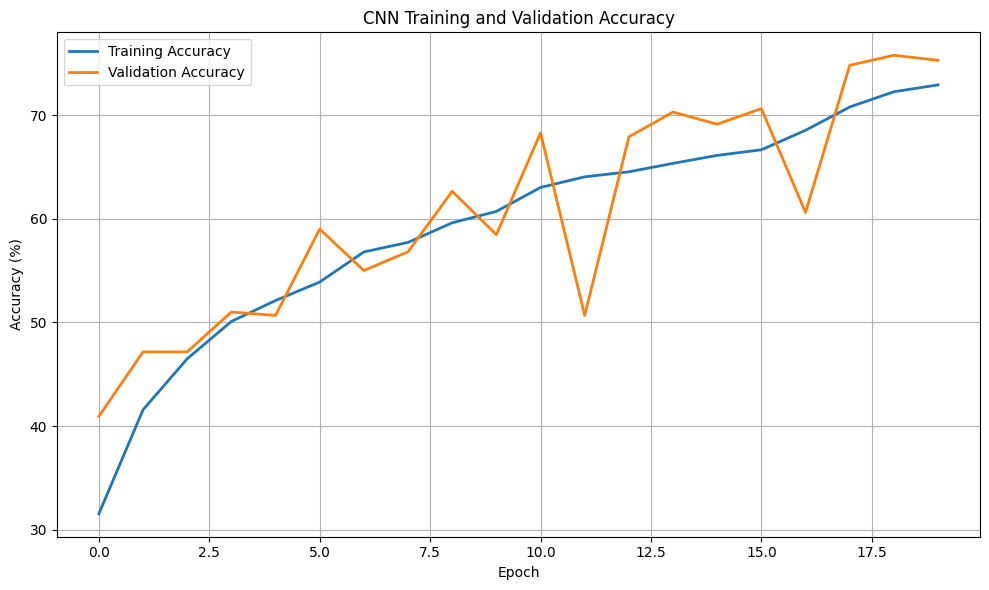

In [ ]:
# ============================================
#  ACCURACY GRAPH
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_accuracies,
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()


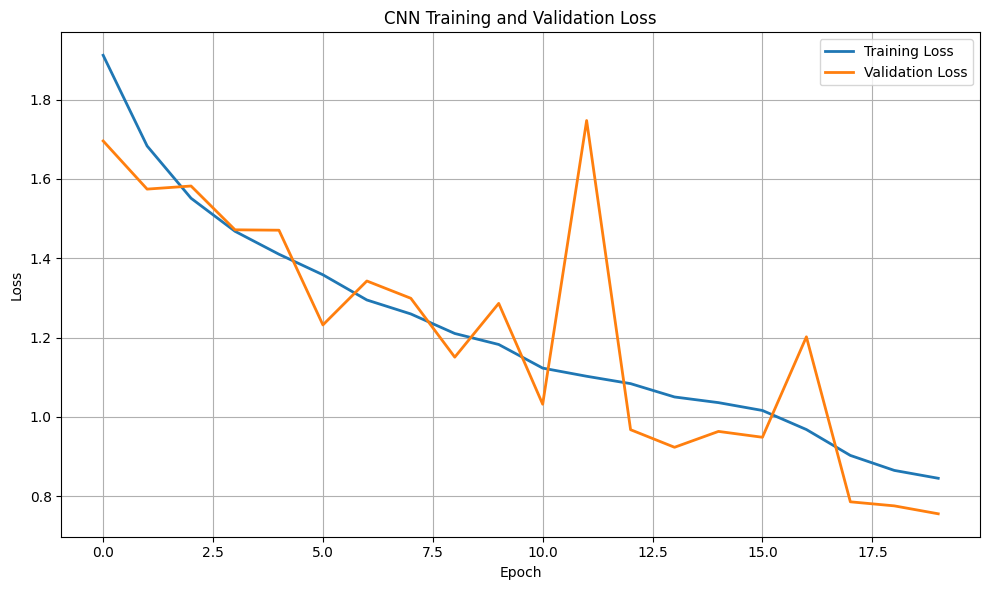

In [ ]:
# ============================================
#  LOSS GRAPH
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()


In [ ]:
# ============================================
#  CNN CLASSIFICATION REPORT
# ============================================

cnn_model.eval()

all_predictions = []
all_labels = []


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = cnn_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


cnn_accuracy = accuracy_score(
    all_labels,
    all_predictions
)


print("=" * 70)
print("CNN FINAL RESULTS")
print("=" * 70)

print(
    f"CNN Validation Accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


CNN FINAL RESULTS
CNN Validation Accuracy: 75.77%

Classification Report:

                 precision    recall  f1-score   support

          tench     0.8872    0.7726    0.8260       387
       springer     0.6673    0.8785    0.7585       395
cassette_player     0.6711    0.8571    0.7528       357
      chain_saw     0.6250    0.5440    0.5817       386
         church     0.8359    0.7971    0.8160       409
    French_horn     0.7980    0.8020    0.8000       394
  garbage_truck     0.8605    0.7455    0.7989       389
       gas_pump     0.6109    0.7494    0.6731       419
      golf_ball     0.8401    0.7243    0.7779       399
      parachute     0.9390    0.7103    0.8088       390

       accuracy                         0.7577      3925
      macro avg     0.7735    0.7581    0.7594      3925
   weighted avg     0.7735    0.7577    0.7593      3925



[[299  48   3  14   0   5   1   3  14   0]
 [  6 347   6  18   5   3   2   8   0   0]
 [  1   4 306   4   3  15   0  22   2   0]
 [ 11  64  33 210   5  19   6  30   8   0]
 [  0   4  10   8 326  11  10  30   7   3]
 [  6  15  11   7   8 316   4  24   3   0]
 [  2   4   9  14   6   3 290  58   0   3]
 [  0   6  41  14  16  12  11 314   5   0]
 [ 10  22  29  13   5   9   1   9 289  12]
 [  2   6   8  34  16   3  12  16  16 277]]


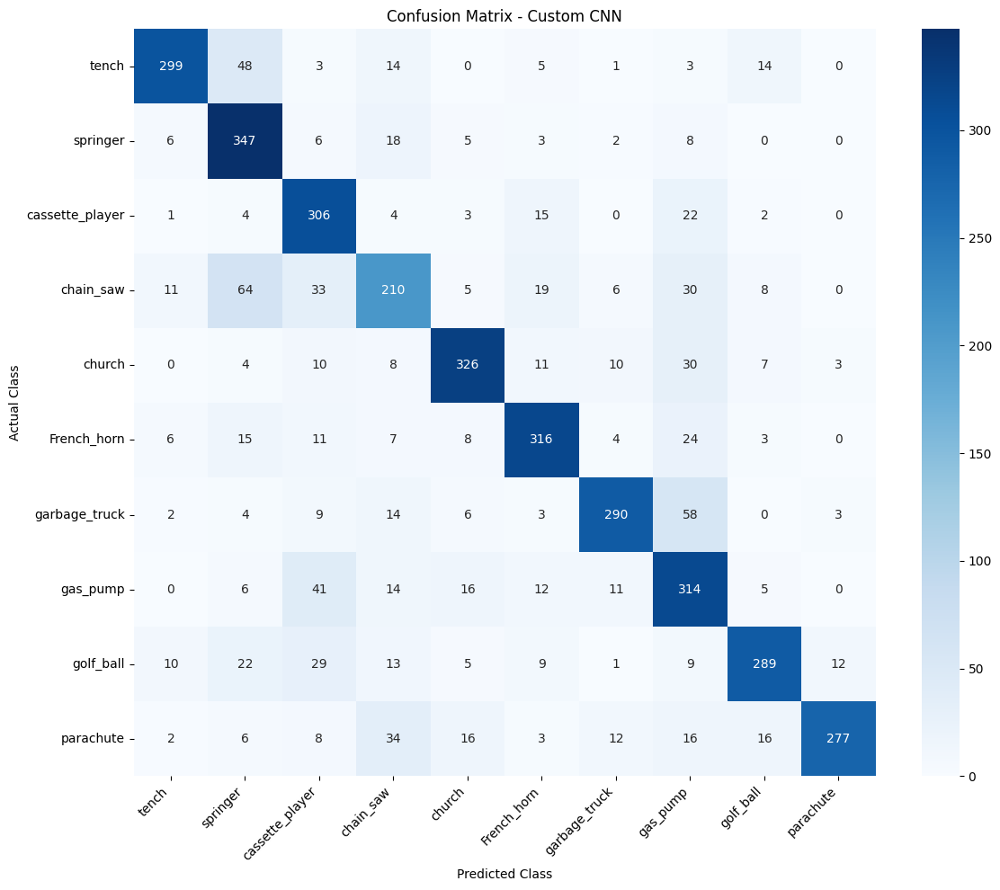

In [ ]:
# ============================================
#  CNN CONFUSION MATRIX
# ============================================

cm_cnn = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm_cnn)

plt.figure(
    figsize=(12, 10)
)


sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix - Custom CNN"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


**CNN Architecture**

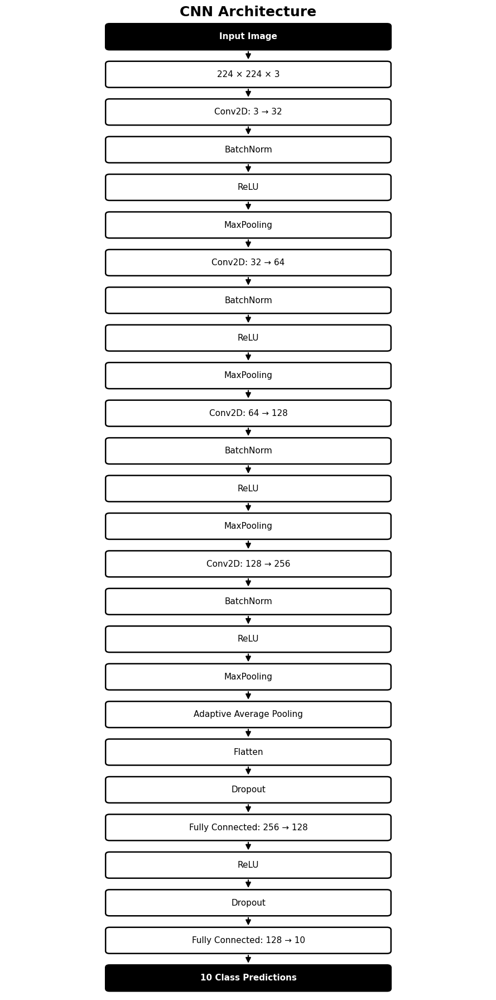

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------
# CNN Architecture Diagram - Black & White
# ---------------------------------------------------------

layers = [
    "Input Image",
    "224 × 224 × 3",

    "Conv2D: 3 → 32",
    "BatchNorm",
    "ReLU",
    "MaxPooling",

    "Conv2D: 32 → 64",
    "BatchNorm",
    "ReLU",
    "MaxPooling",

    "Conv2D: 64 → 128",
    "BatchNorm",
    "ReLU",
    "MaxPooling",

    "Conv2D: 128 → 256",
    "BatchNorm",
    "ReLU",
    "MaxPooling",

    "Adaptive Average Pooling",
    "Flatten",
    "Dropout",

    "Fully Connected: 256 → 128",
    "ReLU",
    "Dropout",

    "Fully Connected: 128 → 10",
    "10 Class Predictions"
]

# Figure
fig, ax = plt.subplots(figsize=(9, 18))

ax.set_xlim(0, 10)
ax.set_ylim(0, len(layers) * 1.15)
ax.axis("off")

# Box dimensions
box_width = 5.8
box_height = 0.72
x = 5

# Vertical spacing
spacing = 1.15

# ---------------------------------------------------------
# Draw nodes
# ---------------------------------------------------------

positions = {}

for i, layer in enumerate(layers):
    y = (len(layers) - i - 1) * spacing + 0.5
    positions[i] = y

    # Different styling for input/output
    if i == 0 or i == len(layers) - 1:
        facecolor = "black"
        textcolor = "white"
    else:
        facecolor = "white"
        textcolor = "black"

    box = FancyBboxPatch(
        (x - box_width / 2, y - box_height / 2),
        box_width,
        box_height,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        linewidth=1.8,
        edgecolor="black",
        facecolor=facecolor
    )

    ax.add_patch(box)

    ax.text(
        x,
        y,
        layer,
        ha="center",
        va="center",
        fontsize=11,
        color=textcolor,
        fontweight="bold" if i == 0 or i == len(layers) - 1 else "normal"
    )

# ---------------------------------------------------------
# Draw directed arrows
# ---------------------------------------------------------

for i in range(len(layers) - 1):

    y_start = positions[i] - box_height / 2
    y_end = positions[i + 1] + box_height / 2

    arrow = FancyArrowPatch(
        (x, y_start),
        (x, y_end),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.5,
        color="black",
        shrinkA=4,
        shrinkB=4
    )

    ax.add_patch(arrow)

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.text(
    5,
    len(layers) * spacing + 0.1,
    "CNN Architecture",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# ---------------------------------------------------------
# Save and display
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "cnn_architecture_black_white.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


**CNN Components**

Convolutional Layers
Four convolutional layers were used to extract visual features.

The number of feature maps increases progressively:

3 --> 32 --> 64 --> 128 --> 256

Early layers learn simple features such as edges and textures, while deeper layers learn more complex patterns.

**Batch Normalization**
Batch normalization was applied after each convolutional layer to improve training stability and convergence.

**ReLU Activation**
The Rectified Linear Unit (ReLU) activation function was used to introduce non-linearity.

**Max Pooling**
Max pooling reduces the spatial dimensions of feature maps while retaining important features.

**Adaptive Average Pooling**
Adaptive average pooling converts the final feature maps into a fixed-size representation.

**Dropout**
Dropout was used in the classifier to reduce overfitting.

The dropout rates were: 0.5, 0.3

**Fully Connected Layers**

The final classifier contains:

256 --> 128 --> 10

The final layer produces 10 outputs, one for each object category.

**Loss Function**

The CNN uses:

"CrossEntropyLoss"

Cross-entropy loss is appropriate for multi-class classification because the model needs to select one class from 10 possible classes.

**Optimizer**

The Adam optimizer was used.

Configuration:

Optimizer: Adam
Learning Rate: 0.001
Weight Decay: 0.0001


A ReduceLROnPlateau learning-rate scheduler was also used.

The scheduler reduces the learning rate when the validation loss stops improving.

**Model Training**

The model was trained for: 20 epochs

with a batch size of: 32

Training was performed using the available computational device:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

The best-performing model was saved based on validation accuracy.

The saved model was: best_cnn_model.pth

**CNN Performance**

The final Custom CNN achieved: Validation Accuracy = 75.77%

The model was evaluated on 3,925 validation images.

This means that the CNN correctly classified approximately: 3,925 × 0.7577 ≈ 2,974 images

Therefore, approximately 2,974 validation images were classified correctly.

**Classification Report**

The final CNN classification results were:

| Class | Precision | Recall | F1-Score | Support |
|:---|---:|---:|---:|---:|
| Tench | 0.8872 | 0.7726 | 0.8260 | 387 |
| Springer | 0.6673 | 0.8785 | 0.7585 | 395 |
| Cassette Player | 0.6711 | 0.8571 | 0.7528 | 357 |
| Chain Saw | 0.6250 | 0.5440 | 0.5817 | 386 |
| Church | 0.8359 | 0.7971 | 0.8160 | 409 |
| French Horn | 0.7980 | 0.8020 | 0.8000 | 394 |
| Garbage Truck | 0.8605 | 0.7455 | 0.7989 | 389 |
| Gas Pump | 0.6109 | 0.7494 | 0.6731 | 419 |
| Golf Ball | 0.8401 | 0.7243 | 0.7779 | 399 |
| Parachute | 0.9390 | 0.7103 | 0.8088 | 390 |
| **Overall Accuracy** | — | — | **75.77%** | **3925** |
| **Macro Average** | **0.7735** | **0.7581** | **0.7594** | — |
| **Weighted Average** | **0.7735** | **0.7577** | **0.7593** | — |

**Precision Analysis**

Precision measures how many images predicted as a particular class actually belong to that class.

The highest precision was obtained for:

Parachute — 93.90%

followed by:

Tench — 88.72%

Garbage Truck — 86.05%

Golf Ball — 84.01%

Church — 83.59%

The lowest precision was obtained for:

Gas Pump — 61.09%

followed by:

Chain Saw — 62.50%

This indicates that the CNN sometimes incorrectly predicts images from other categories as gas pumps or chain saws.

**Recall Analysis**

Recall measures how many images belonging to a particular class were correctly identified.

The highest recall was:

Springer — 87.85%

followed by:

Cassette Player — 85.71%

French Horn — 80.20%

Church — 79.71%

Tench — 77.26%

The weakest recall was:

Chain Saw — 54.40%

This means that nearly half of the actual chain-saw images were classified as another category.

**F1-Score Analysis**

F1-score combines precision and recall.

The strongest F1-scores were:

| Class | F1-Score |
|:---|---:|
| Tench | 82.60% |
| Church | 81.60% |
| Parachute | 80.88% |
| French Horn | 80.00% |
| Garbage Truck | 79.89% |

The weakest F1-score was:

Chain Saw — 58.17%

The second weakest was:

Gas Pump — 67.31%

Therefore, chain saw and gas pump are the classes that require the most improvement.

**Confusion Matrix Analysis**

The CNN confusion matrix was:

| Actual \ Predicted | Tench | Springer | Cassette Player | Chain Saw | Church | French Horn | Garbage Truck | Gas Pump | Golf Ball | Parachute |
|:---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **Tench** | 299 | 48 | 3 | 14 | 0 | 5 | 1 | 3 | 14 | 0 |
| **Springer** | 6 | 347 | 6 | 18 | 5 | 3 | 2 | 8 | 0 | 0 |
| **Cassette Player** | 1 | 4 | 306 | 4 | 3 | 15 | 0 | 22 | 2 | 0 |
| **Chain Saw** | 11 | 64 | 33 | 210 | 5 | 19 | 6 | 30 | 8 | 0 |
| **Church** | 0 | 4 | 10 | 8 | 326 | 11 | 10 | 30 | 7 | 3 |
| **French Horn** | 6 | 15 | 11 | 7 | 8 | 316 | 4 | 24 | 3 | 0 |
| **Garbage Truck** | 2 | 4 | 9 | 14 | 6 | 3 | 290 | 58 | 0 | 3 |
| **Gas Pump** | 0 | 6 | 41 | 14 | 16 | 12 | 11 | 314 | 5 | 0 |
| **Golf Ball** | 10 | 22 | 29 | 13 | 5 | 9 | 1 | 9 | 289 | 12 |
| **Parachute** | 2 | 6 | 8 | 34 | 16 | 3 | 12 | 16 | 16 | 277 |

**Important Classification Errors**

The largest confusion occurs with the chain saw category.

Out of 386 actual chain-saw images:

210 --> correctly classified as chain saw

64  --> predicted as springer

33  --> predicted as cassette player

30  --> predicted as gas pump

19  --> predicted as French horn

This explains the low chain-saw recall of 54.40%.

Another significant confusion occurs with garbage truck and gas pump

Garbage truck --> Gas pump = 58

Gas pump --> Cassette player = 41

Gas pump --> Chain saw = 14

These errors suggest that the custom CNN has difficulty learning sufficiently discriminative visual features for some categories.

**Strengths of the CNN**

The custom CNN has several advantages.

**Simple Architecture**

The model is relatively straightforward and easy to understand.

**Efficient Training**

Compared with deeper architectures, a custom CNN generally requires fewer computational resources.

**End-to-End Learning**

The model automatically learns useful visual features directly from the images.

**Good Performance on Several Classes**

The CNN achieved F1-scores above 80% for several classes, particularly:

Tench

Church

Parachute

French Horn

Balanced Dataset

The relatively balanced number of images across categories reduces the risk of severe class imbalance.

**Limitations of the CNN**

Despite achieving 75.77% accuracy, the CNN has some limitations.

**Lower Accuracy Than ResNet-18**

The CNN achieved:

75.77%

**while ResNet-18 achieved:**

97.35%

**This is a difference of:**

21.58 percentage points.

Difficulty With Similar Visual Patterns

The CNN struggles particularly with:

Chain Saw

Gas Pump

Cassette Player

Springer

**Limited Network Depth**

The custom CNN has only four convolutional blocks. A deeper architecture can learn more complex representations.

**No Transfer Learning**

The custom CNN was trained from scratch, whereas architectures such as ResNet-18 can benefit from pretrained visual features.















**Comparison With ResNet-18**

The two models were evaluated on the same validation dataset.

| Metric | Custom CNN | ResNet-18 |
|:---|---:|---:|
| Validation Images | 3,925 | 3,925 |
| Accuracy | 75.77% | 97.35% |
| Macro Precision | 77.35% | 97.36% |
| Macro Recall | 75.81% | 97.35% |
| Macro F1 | 75.94% | 97.35% |

**Result**

ResNet-18 is the better-performing model.

The improvement is: 97.35 - 75.77 = 21.58 percentage points

This demonstrates the advantage of deeper architectures and residual connections for this image-classification task.

**Business Interpretation**

From a business perspective, the CNN demonstrates that automated image classification is feasible for the selected object categories.

A system based on this approach could potentially be used for:

- Automated image organization
- Image search and categorization
- Inventory image classification
- Visual inspection
- Educational image recognition
- Automated dataset labelling
- Content management systems

However, because the CNN produces approximately 75.77% validation accuracy, it may require further improvement before being deployed in applications where classification errors have significant consequences.

For a production-oriented solution, the ResNet-18 model is currently preferable based on the experimental results.


**Conclusion**

The dataset contained 9,470 training images and 3,925 validation images distributed across 10 categories. Images were resized to 224 × 224 pixels and normalized, while data augmentation techniques were applied to the training data.

The custom CNN achieved a validation accuracy of 75.77%, with a macro F1-score of 75.94%. The model performed particularly well on the Tench, Church, Parachute and French Horn categories. However, it experienced considerable difficulty distinguishing Chain Saw and Gas Pump images.

A comparison with ResNet-18 showed that ResNet-18 achieved 97.35% validation accuracy, outperforming the custom CNN by 21.58 percentage points.

Therefore, the experiment demonstrates that a custom CNN can successfully learn the visual characteristics of the 10 object categories, but a deeper architecture such as ResNet-18 provides substantially better classification performance for this dataset.

**Final result:** Custom CNN = 75.77%; ResNet-18 = 97.35%. ResNet-18 is the recommended model based on validation performance.

**CNN with data augmentation**

In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# ============================================
#  CLASS MAPPING
# ============================================

class_map = {
    "n01440764": "tench",
    "n02102040": "springer",
    "n02979186": "cassette_player",
    "n03000684": "chain_saw",
    "n03028079": "church",
    "n03394916": "French_horn",
    "n03417042": "garbage_truck",
    "n03425413": "gas_pump",
    "n03445777": "golf_ball",
    "n03888257": "parachute"
}

print("Classes:")
for i, (folder, name) in enumerate(class_map.items()):
    print(f"{i}: {name} ({folder})")


Classes:
0: tench (n01440764)
1: springer (n02102040)
2: cassette_player (n02979186)
3: chain_saw (n03000684)
4: church (n03028079)
5: French_horn (n03394916)
6: garbage_truck (n03417042)
7: gas_pump (n03425413)
8: golf_ball (n03445777)
9: parachute (n03888257)


**Data Augmentation**

In [ ]:
# ============================================
# DATA TRANSFORMS WITH AUGMENTATION
# ============================================

IMG_SIZE = 224

# --------------------------------------------
# TRAINING TRANSFORMS
# --------------------------------------------

train_transform = transforms.Compose([

    # Resize image
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # -----------------------------
    # DATA AUGMENTATION
    # -----------------------------

    # Randomly flip image horizontally
    transforms.RandomHorizontalFlip(p=0.5),

    # Random rotation
    transforms.RandomRotation(
        degrees=15
    ),

    # Randomly change brightness,
    # contrast, saturation and hue
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Randomly crop and resize
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # Normalize
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------
# VALIDATION TRANSFORMS
# --------------------------------------------

val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformations created.")
print("Validation transformations created.")


Training transformations created.
Validation transformations created.


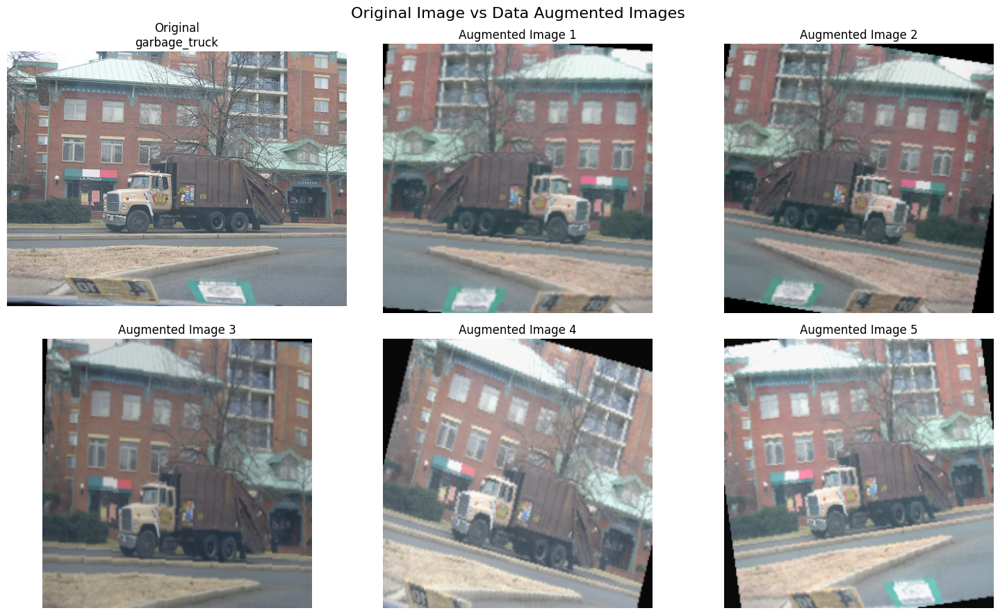

In [ ]:
# ============================================
# DISPLAY ORIGINAL VS AUGMENTED IMAGES
# ============================================

import matplotlib.pyplot as plt
from PIL import Image
import random

# Select one class
class_folder = random.choice(
    [f for f in TRAIN_DIR.iterdir() if f.is_dir()]
)

# Select one original image
image_files = [
    f for f in class_folder.iterdir()
    if f.is_file()
]

image_path = random.choice(image_files)

# Load original image
original_image = Image.open(image_path).convert("RGB")

# Generate augmented versions
augmented_images = []

for i in range(5):
    augmented_image = train_transform(original_image)
    augmented_images.append(augmented_image)

# ============================================
# FUNCTION TO DISPLAY NORMALIZED TENSOR
# ============================================

def tensor_to_image(tensor):

    image = tensor.numpy().transpose(1, 2, 0)

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    image = image * std + mean

    image = image.clip(0, 1)

    return image


# ============================================
# PLOT
# ============================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

# Original image
axes[0].imshow(original_image)
axes[0].set_title(
    f"Original\n{class_map[class_folder.name]}",
    fontsize=12
)
axes[0].axis("off")

# Augmented images
for i, image_tensor in enumerate(augmented_images):

    axes[i + 1].imshow(
        tensor_to_image(image_tensor)
    )

    axes[i + 1].set_title(
        f"Augmented Image {i + 1}",
        fontsize=12
    )

    axes[i + 1].axis("off")

plt.suptitle(
    "Original Image vs Data Augmented Images",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# CREATE DATASETS
# ============================================

from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)


Training images: 9470
Validation images: 3925

Classes:
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']

Class mapping:
{'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}


In [ ]:
# ============================================
# CREATE DATALOADERS
# ============================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 296
Validation batches: 123


In [ ]:
# ============================================
# CHECK ONE BATCH
# ============================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([1, 4, 5, 2, 0, 5, 5, 8, 4, 6])


In [ ]:
# ============================================
# CNN MODEL
# ============================================

import torch.nn as nn

class CNN(nn.Module):

    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


In [ ]:
# ============================================
# CREATE MODEL
# ============================================

model = CNN(num_classes=10).to(device)

print(model)
print("\nModel device:", next(model.parameters()).device)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

In [ ]:
# ============================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss function and optimizer created.")


Loss function and optimizer created.


In [ ]:
# ============================================
# LEARNING RATE SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Learning-rate scheduler created.")


Learning-rate scheduler created.


In [ ]:
# ============================================
# TRAIN CNN WITH DATA AUGMENTATION
# ============================================

import time
import copy
import torch

NUM_EPOCHS = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

print("=" * 80)
print("STARTING CNN TRAINING WITH DATA AUGMENTATION")
print("=" * 80)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAINING
    # ========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_train_loss = (
        running_loss / total
    )

    epoch_train_accuracy = (
        100 * correct / total
    )

    # ========================================
    # VALIDATION
    # ========================================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    epoch_val_loss = (
        running_val_loss / val_total
    )

    epoch_val_accuracy = (
        100 * val_correct / val_total
    )

    # ========================================
    # SAVE HISTORY
    # ========================================

    train_losses.append(
        epoch_train_loss
    )

    train_accuracies.append(
        epoch_train_accuracy
    )

    val_losses.append(
        epoch_val_loss
    )

    val_accuracies.append(
        epoch_val_accuracy
    )

    # ========================================
    # UPDATE LEARNING RATE
    # ========================================

    scheduler.step(epoch_val_loss)

    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            model.state_dict(),
            "/content/best_cnn_augmented.pth"
        )

        best_marker = "BEST"

    else:
        best_marker = ""

    # ========================================
    # PRINT RESULTS
    # ========================================

    epoch_time = time.time() - start_time

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    "Best model:"
)

print(
    "/content/best_cnn_augmented.pth"
)


STARTING CNN TRAINING WITH DATA AUGMENTATION
Epoch [01/20] | Train Loss: 1.6576 | Train Acc: 42.22% | Val Loss: 1.9822 | Val Acc: 36.51% | LR: 0.001000 | Time: 154.3sBEST
Epoch [02/20] | Train Loss: 1.5328 | Train Acc: 47.61% | Val Loss: 1.9726 | Val Acc: 34.60% | LR: 0.001000 | Time: 152.4s
Epoch [03/20] | Train Loss: 1.4582 | Train Acc: 50.60% | Val Loss: 1.7055 | Val Acc: 47.75% | LR: 0.001000 | Time: 153.5sBEST
Epoch [04/20] | Train Loss: 1.3930 | Train Acc: 53.25% | Val Loss: 1.2361 | Val Acc: 59.54% | LR: 0.001000 | Time: 153.3sBEST
Epoch [05/20] | Train Loss: 1.3414 | Train Acc: 55.40% | Val Loss: 1.1947 | Val Acc: 60.46% | LR: 0.001000 | Time: 154.7sBEST
Epoch [06/20] | Train Loss: 1.2821 | Train Acc: 57.54% | Val Loss: 1.2873 | Val Acc: 55.49% | LR: 0.001000 | Time: 153.7s
Epoch [07/20] | Train Loss: 1.2295 | Train Acc: 59.81% | Val Loss: 1.1790 | Val Acc: 62.22% | LR: 0.001000 | Time: 153.3sBEST
Epoch [08/20] | Train Loss: 1.1945 | Train Acc: 60.94% | Val Loss: 1.3552 | Val A

In [ ]:
# ============================================
# LOAD BEST AUGMENTED CNN
# ============================================

import torch

model.load_state_dict(
    torch.load(
        "/content/best_cnn_augmented.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best augmented CNN model loaded successfully.")


Best augmented CNN model loaded successfully.


In [ ]:
# ============================================
# CLASSIFICATION REPORT
# CNN + DATA AUGMENTATION
# ============================================

from sklearn.metrics import classification_report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("=" * 80)
print("CNN + DATA AUGMENTATION")
print("=" * 80)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


CNN + DATA AUGMENTATION
                 precision    recall  f1-score   support

          tench     0.8276    0.8682    0.8474       387
       springer     0.8806    0.8025    0.8397       395
cassette_player     0.7000    0.8431    0.7649       357
      chain_saw     0.5690    0.6192    0.5931       386
         church     0.8740    0.7800    0.8243       409
    French_horn     0.7969    0.7868    0.7918       394
  garbage_truck     0.7243    0.9049    0.8046       389
       gas_pump     0.7798    0.6086    0.6836       419
      golf_ball     0.9007    0.6591    0.7612       399
      parachute     0.7667    0.8846    0.8214       390

       accuracy                         0.7738      3925
      macro avg     0.7820    0.7757    0.7732      3925
   weighted avg     0.7837    0.7738    0.7731      3925



[[336   3   4  21   0   2   4   1   9   7]
 [  9 317   0  41   3   6   6   5   4   4]
 [  0   2 301   9   3  12  14  10   3   3]
 [ 17  13  19 239   3  20  25  17   5  28]
 [  4   3   8   9 319  18  16  16   2  14]
 [ 15   6  12  23   5 310   8  12   0   3]
 [  1   1   5  14   5   2 352   4   0   5]
 [  2   1  55  26  16   7  50 255   2   5]
 [ 17  12  21  25   7   8   5   5 263  36]
 [  5   2   5  13   4   4   6   2   4 345]]


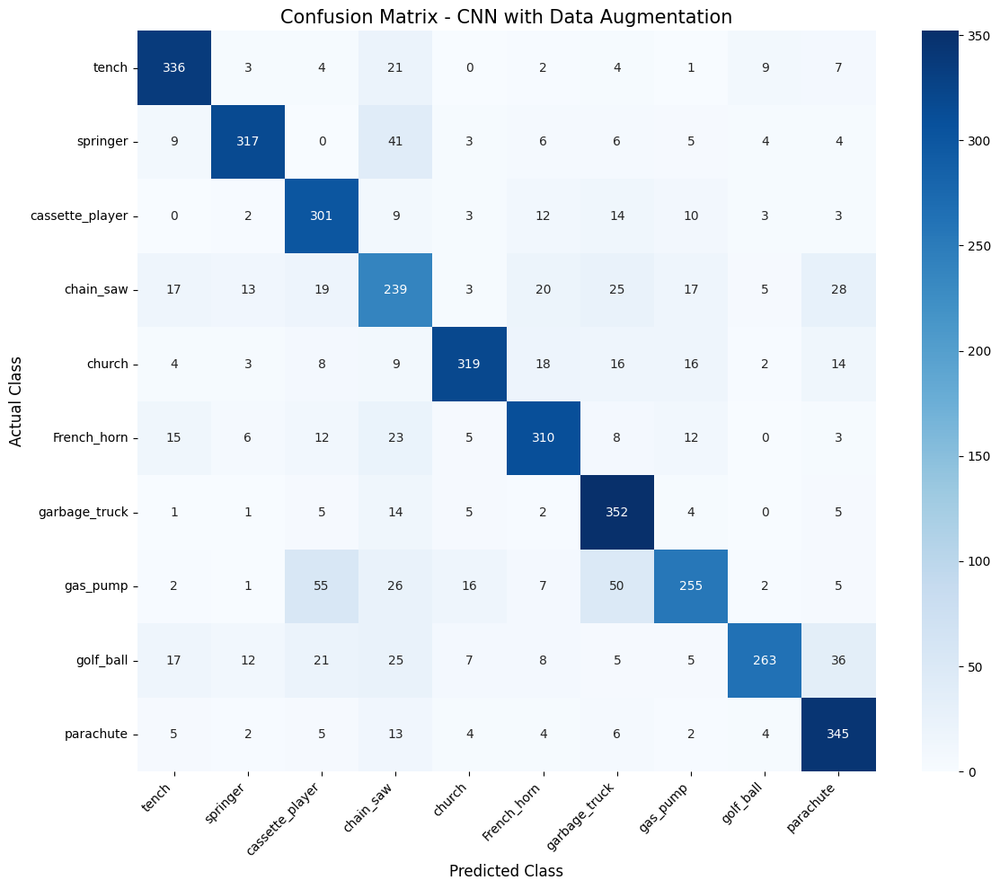

In [ ]:
# ============================================
# CONFUSION MATRIX
# CNN + DATA AUGMENTATION
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_aug = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm_aug)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_aug,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.title(
    "Confusion Matrix - CNN with Data Augmentation",
    fontsize=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


**CNN + Data Augmentation Results**

The CNN model was evaluated on 3,925 validation images across 10 classes. Data augmentation was applied only to the training dataset, while the validation images were resized and normalized without augmentation.

The model achieved:

Validation Accuracy: 77.38%
Macro F1-score: 77.32%
Weighted F1-score: 77.31%

Class-wise performance

| Class | Precision | Recall | F1-score |
|:---|---:|---:|---:|
| Tench | 82.76% | 86.82% | 84.74% |
| Springer | 88.06% | 80.25% | 83.97% |
| Cassette Player | 70.00% | 84.31% | 76.49% |
| Chain Saw | 56.90% | 61.92% | 59.31% |
| Church | 87.40% | 78.00% | 82.43% |
| French Horn | 79.69% | 78.68% | 79.18% |
| Garbage Truck | 72.43% | 90.49% | 80.46% |
| Gas Pump | 77.98% | 60.86% | 68.36% |
| Golf Ball | 90.07% | 65.91% | 76.12% |
| Parachute | 76.67% | 88.46% | 82.14% |




**Confusion Matrix Analysis**

The confusion matrix shows that the model performs well for several classes, but some classes remain difficult to distinguish.

**Strong classifications**

Garbage truck had the highest recall at 90.49%, with 352 of 389 images correctly classified.
Parachute also performed well, with 88.46% recall and 345 correct predictions.

Tench achieved 86.82% recall, with 336 correctly classified images.
Cassette player achieved 84.31% recall.

**Difficult classifications**

The weakest class was chain saw, with an F1-score of only 59.31%. Only 239 of 386 chain-saw images were correctly classified.

The model also struggled with:

- Gas pump: 60.86% recall
- Golf ball: 65.91% recall
- Church: 78.00% recall
- French horn: 78.68% recall

The confusion matrix shows particularly noticeable confusion between gas pump and cassette player/garbage truck, and between chain saw and several other classes.

For example, among the 419 gas-pump images, only 255 were correctly classified. A significant number were predicted as cassette player (55) and garbage truck (50).

Similarly, among the 386 chain-saw images, only 239 were correctly classified. The model confused chain saw with tench, cassette player, French horn, garbage truck, gas pump, and parachute.

**Effect of Data Augmentation**

This is an important part of your project because you have results from both versions of the CNN.

| Model | Augmentation | Validation Accuracy |
|:---|:---:|---:|
| CNN | No | 75.77% |
| CNN | Yes | 77.38% |
| ResNet-18 | No | 97.35% |

Data augmentation improved the CNN from 75.77% to 77.38%, an improvement of 1.61 percentage points.

This indicates that augmentation provided a modest improvement in the CNN's ability to generalize to unseen validation images.

However, the ResNet-18 model substantially outperformed both CNN versions, achieving 97.35% validation accuracy.

**Conclusion**

A Convolutional Neural Network (CNN) was trained to classify the 10 image categories in the dataset. To improve the model's ability to generalize, data augmentation was applied only to the training dataset. The augmentation techniques included random horizontal flipping, random rotation, color jittering, and random resized cropping. The validation dataset was not augmented; it was only resized and normalized to ensure that evaluation was performed on consistent, unmodified images.

The CNN with data augmentation achieved a validation accuracy of 77.38% on 3,925 validation images. The macro-average F1-score was 77.32%, while the weighted-average F1-score was 77.31%.

Among the individual classes, tench achieved an F1-score of 84.74%, while springer achieved 83.97%. The garbage truck class achieved the highest recall at 90.49%, indicating that most garbage-truck images were correctly identified. The parachute class also performed strongly, achieving a recall of 88.46%.

The most challenging class was chain saw, which achieved an F1-score of 59.31%. The model also showed relatively weaker performance for gas pump, with an F1-score of 68.36%, and golf ball, with an F1-score of 76.12%. The confusion matrix indicates that these classes were frequently confused with visually similar or contextually related categories.

The effect of data augmentation was evaluated by comparing the augmented CNN with the original CNN. The original CNN achieved 75.77% validation accuracy, whereas the augmented CNN achieved 77.38%. Therefore, data augmentation resulted in an improvement of 1.61 percentage points. This demonstrates that augmentation provided a modest improvement in generalization performance.

Although the augmented CNN performed better than the original CNN, the ResNet-18 model achieved a considerably higher validation accuracy of 97.35%. This suggests that the deeper residual architecture was substantially more effective at learning discriminative visual features from this dataset.

Overall, the CNN with data augmentation successfully classified the 10 target categories and demonstrated improved performance compared with the CNN without augmentation. However, ResNet-18 provided the strongest classification performance among the evaluated models.

**ResNet-18 datasets with augmentation**

In [ ]:
# ============================================
# RESNET-18 DATASETS WITH AUGMENTATION
# ============================================

from torchvision import datasets
from torch.utils.data import DataLoader

resnet_train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

resnet_val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("Training images:", len(resnet_train_dataset))
print("Validation images:", len(resnet_val_dataset))


Training images: 9470
Validation images: 3925


**Create DataLoaders**

In [ ]:
# ============================================
# RESNET-18 DATALOADERS
# ============================================

BATCH_SIZE = 32

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(resnet_train_loader))
print("Validation batches:", len(resnet_val_loader))


Train batches: 296
Validation batches: 123


**Create a new Resnet18 model**

In [ ]:
# ============================================
# RESNET-18 WITH DATA AUGMENTATION
# ============================================

import torch
import torch.nn as nn
from torchvision import models

resnet_aug = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Replace final layer for 10 classes
num_features = resnet_aug.fc.in_features

resnet_aug.fc = nn.Linear(
    num_features,
    10
)

resnet_aug = resnet_aug.to(device)

print("ResNet-18 with augmentation created.")
print("Device:", device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.3MB/s]


ResNet-18 with augmentation created.
Device: cuda


In [ ]:
# ============================================
# LOSS AND OPTIMIZER
# ============================================

criterion_resnet_aug = nn.CrossEntropyLoss()

optimizer_resnet_aug = torch.optim.Adam(
    resnet_aug.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_resnet_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet_aug,
    mode="min",
    factor=0.5,
    patience=2
)

print("Optimizer and scheduler ready.")


Optimizer and scheduler ready.


In [ ]:
# ============================================
# TRAIN RESNET-18 WITH DATA AUGMENTATION
# ============================================

import time
import copy

NUM_EPOCHS = 15

resnet_train_losses = []
resnet_train_accuracies = []

resnet_val_losses = []
resnet_val_accuracies = []

best_resnet_val_accuracy = 0.0

best_resnet_weights = copy.deepcopy(
    resnet_aug.state_dict()
)

print("=" * 80)
print("RESNET-18 TRAINING WITH DATA AUGMENTATION")
print("=" * 80)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAINING
    # ========================================

    resnet_aug.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer_resnet_aug.zero_grad()

        outputs = resnet_aug(images)

        loss = criterion_resnet_aug(
            outputs,
            labels
        )

        loss.backward()

        optimizer_resnet_aug.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    # ========================================
    # VALIDATION
    # ========================================

    resnet_aug.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in resnet_val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = resnet_aug(images)

            loss = criterion_resnet_aug(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = running_val_loss / val_total

    val_accuracy = (
        100 * val_correct / val_total
    )

    # ========================================
    # SAVE HISTORY
    # ========================================

    resnet_train_losses.append(train_loss)
    resnet_train_accuracies.append(train_accuracy)

    resnet_val_losses.append(val_loss)
    resnet_val_accuracies.append(val_accuracy)

    # ========================================
    # SCHEDULER
    # ========================================

    scheduler_resnet_aug.step(val_loss)

    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if val_accuracy > best_resnet_val_accuracy:

        best_resnet_val_accuracy = val_accuracy

        best_resnet_weights = copy.deepcopy(
            resnet_aug.state_dict()
        )

        torch.save(
            resnet_aug.state_dict(),
            "/content/best_resnet18_augmented.pth"
        )

        best_marker = "BEST"

    else:
        best_marker = ""

    # ========================================
    # PRINT
    # ========================================

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best ResNet-18 validation accuracy: "
    f"{best_resnet_val_accuracy:.2f}%"
)

print(
    "Model saved at:"
)

print(
    "/content/best_resnet18_augmented.pth"
)


RESNET-18 TRAINING WITH DATA AUGMENTATION
Epoch [01/15] | Train Loss: 0.2881 | Train Acc: 91.66% | Val Loss: 0.1074 | Val Acc: 96.54% | Time: 164.9s ⭐ BEST
Epoch [02/15] | Train Loss: 0.1191 | Train Acc: 96.43% | Val Loss: 0.1249 | Val Acc: 95.92% | Time: 161.6s
Epoch [03/15] | Train Loss: 0.0782 | Train Acc: 97.75% | Val Loss: 0.1049 | Val Acc: 96.99% | Time: 161.3s ⭐ BEST
Epoch [04/15] | Train Loss: 0.0674 | Train Acc: 97.94% | Val Loss: 0.1042 | Val Acc: 97.20% | Time: 160.6s ⭐ BEST
Epoch [05/15] | Train Loss: 0.0456 | Train Acc: 98.86% | Val Loss: 0.1329 | Val Acc: 95.77% | Time: 159.2s
Epoch [06/15] | Train Loss: 0.0459 | Train Acc: 98.64% | Val Loss: 0.1263 | Val Acc: 96.51% | Time: 156.9s
Epoch [07/15] | Train Loss: 0.0360 | Train Acc: 98.86% | Val Loss: 0.1348 | Val Acc: 95.69% | Time: 157.6s
Epoch [08/15] | Train Loss: 0.0318 | Train Acc: 98.95% | Val Loss: 0.1004 | Val Acc: 96.82% | Time: 156.0s
Epoch [09/15] | Train Loss: 0.0147 | Train Acc: 99.65% | Val Loss: 0.1045 | Val A

In [ ]:
# ============================================
# LOAD BEST RESNET-18 AUGMENTED MODEL
# ============================================

import torch

resnet_aug.load_state_dict(
    torch.load(
        "/content/best_resnet18_augmented.pth",
        map_location=device
    )
)

resnet_aug = resnet_aug.to(device)
resnet_aug.eval()

print("Best ResNet-18 augmented model loaded successfully.")


Best ResNet-18 augmented model loaded successfully.


In [ ]:
# ============================================
# CLASSIFICATION REPORT
# RESNET-18 + DATA AUGMENTATION
# ============================================

from sklearn.metrics import classification_report

resnet_aug.eval()

all_predictions_resnet_aug = []
all_labels_resnet_aug = []

with torch.no_grad():

    for images, labels in resnet_val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_aug(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions_resnet_aug.extend(
            predictions.cpu().numpy()
        )

        all_labels_resnet_aug.extend(
            labels.cpu().numpy()
        )

print("=" * 80)
print("RESNET-18 + DATA AUGMENTATION")
print("=" * 80)

print(
    classification_report(
        all_labels_resnet_aug,
        all_predictions_resnet_aug,
        target_names=class_names,
        digits=4
    )
)


RESNET-18 + DATA AUGMENTATION
                 precision    recall  f1-score   support

          tench     0.9846    0.9897    0.9871       387
       springer     0.9898    0.9848    0.9873       395
cassette_player     0.9388    0.9888    0.9632       357
      chain_saw     0.9553    0.9404    0.9478       386
         church     0.9877    0.9780    0.9828       409
    French_horn     0.9749    0.9848    0.9798       394
  garbage_truck     0.9973    0.9563    0.9764       389
       gas_pump     0.9547    0.9547    0.9547       419
      golf_ball     0.9825    0.9850    0.9837       399
      parachute     0.9745    0.9795    0.9770       390

       accuracy                         0.9740      3925
      macro avg     0.9740    0.9742    0.9740      3925
   weighted avg     0.9743    0.9740    0.9740      3925



[[383   0   0   2   0   0   0   0   1   1]
 [  0 389   1   2   1   1   0   0   1   0]
 [  0   0 353   2   0   0   0   2   0   0]
 [  1   3   5 363   1   6   0   3   2   2]
 [  0   1   0   0 400   0   0   3   1   4]
 [  0   0   1   2   1 388   0   0   1   1]
 [  1   0   1   4   0   0 372  11   0   0]
 [  1   0  13   3   0   1   1 400   0   0]
 [  3   0   1   0   0   0   0   0 393   2]
 [  0   0   1   2   2   2   0   0   1 382]]


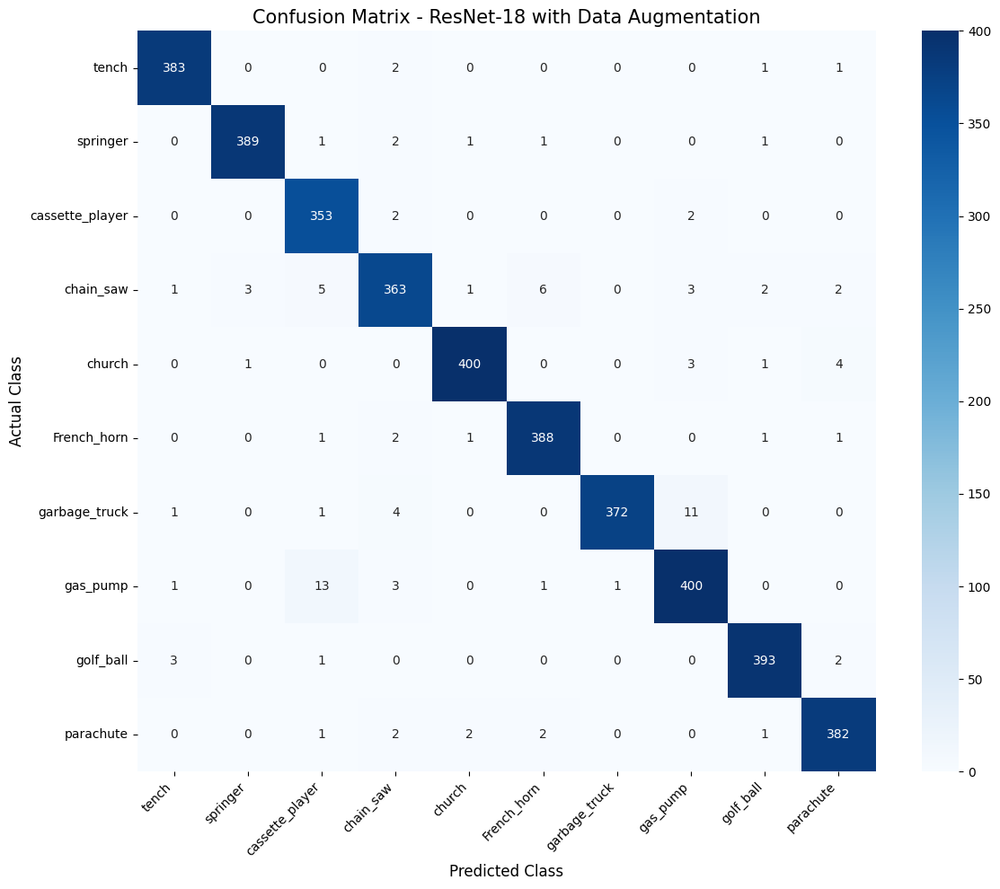

In [ ]:
# ============================================
# CONFUSION MATRIX
# RESNET-18 + DATA AUGMENTATION
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_resnet_aug = confusion_matrix(
    all_labels_resnet_aug,
    all_predictions_resnet_aug
)

print(cm_resnet_aug)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_resnet_aug,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.title(
    "Confusion Matrix - ResNet-18 with Data Augmentation",
    fontsize=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


**ResNet-18 + Data Augmentation Results**

The model achieved:

- Validation Accuracy: 97.40%
- Macro F1-score: 97.40%
- Weighted F1-score: 97.40%
- Validation images: 3,925
- Number of classes: 10

Class-wise performance

| Class | Precision | Recall | F1-score |
|:---|---:|---:|---:|
| Tench | 98.46% | 98.97% | 98.71% |
| Springer | 98.98% | 98.48% | 98.73% |
| Cassette Player | 93.88% | 98.88% | 96.32% |
| Chain Saw | 95.53% | 94.04% | 94.78% |
| Church | 98.77% | 97.80% | 98.28% |
| French Horn | 97.49% | 98.48% | 97.98% |
| Garbage Truck | 99.73% | 95.63% | 97.64% |
| Gas Pump | 95.47% | 95.47% | 95.47% |
| Golf Ball | 98.25% | 98.50% | 98.37% |
| Parachute | 97.45% | 97.95% | 97.70% |




**Confusion Matrix Analysis**

The confusion matrix is excellent because most values are concentrated on the diagonal, meaning the majority of images were classified correctly.

For example:

- Tench: 383/387 correctly classified
- Springer: 389/395 correctly classified
- Cassette player: 353/357 correctly classified
- Chain saw: 363/386 correctly classified
- Church: 400/409 correctly classified
- French horn: 388/394 correctly classified
- Garbage truck: 372/389 correctly classified
- Gas pump: 400/419 correctly classified
- Golf ball: 393/399 correctly classified
- Parachute: 382/390 correctly classified

The largest noticeable confusion is around gas pump, where some images were predicted as cassette player. Chain saw also has a few misclassifications involving springer, cassette player, French horn, and gas pump.

However, these errors are relatively small compared with the total validation set.

**Model Comparison**

| Model | Augmentation | Accuracy |
|:---|:---:|---:|
| CNN | No | 75.77% |
| CNN | Yes | 77.38% |
| ResNet-18 | No | 97.35% |
| ResNet-18 | Yes | 97.40% |

Improvement from augmentation
CNN:

75.77% --> 77.38%

Improvement = +1.61 percentage points

ResNet-18:

97.35% --> 97.40%

Improvement = +0.05 percentage points


**Conclusion**

The results demonstrate that data augmentation had a much larger effect on the basic CNN than on ResNet-18. The CNN improved by 1.61 percentage points, while ResNet-18 improved only marginally by 0.05 percentage points.

This makes sense because ResNet-18 already has a substantially stronger feature-extraction capability and achieved 97.35% without augmentation.

The best-performing model is ResNet-18 with data augmentation at 97.40% validation accuracy.

**ResNet-50**

In [ ]:
# ============================================
# RESNET-50 WITHOUT AUGMENTATION
# ============================================

import os
import time
import copy
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ============================================
# DEVICE
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================
# TRANSFORMS WITHOUT AUGMENTATION
# ============================================

from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


In [ ]:
# ============================================
# LOAD DATASETS
# ============================================

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("Number of training images:",
      len(train_dataset))

print("Number of validation images:",
      len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)


Number of training images: 9470
Number of validation images: 3925

Classes:
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


In [ ]:
print("\nClass-to-index mapping:")

for class_name, index in train_dataset.class_to_idx.items():
    print(index, "->", class_name)



Class-to-index mapping:
0 -> n01440764
1 -> n02102040
2 -> n02979186
3 -> n03000684
4 -> n03028079
5 -> n03394916
6 -> n03417042
7 -> n03425413
8 -> n03445777
9 -> n03888257


In [ ]:
# ============================================
# DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:",
      len(train_loader))

print("Validation batches:",
      len(val_loader))


Training batches: 296
Validation batches: 123


In [ ]:
# ============================================
# RESNET-50
# ============================================

NUM_CLASSES = 10

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Number of features entering final layer
num_features = model.fc.in_features

print(
    "Original FC input features:",
    num_features
)

# Replace final layer
model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print("\nResNet-50 model created.")
print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 67.8MB/s]


Original FC input features: 2048

ResNet-50 model created.
Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
# ============================================
# LOSS FUNCTION
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# OPTIMIZER
# ============================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)


# ============================================
# LEARNING RATE SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


In [ ]:
# ============================================
# TRAINING
# ============================================

NUM_EPOCHS = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(
    model.state_dict()
)

print("=" * 80)
print("STARTING RESNET-50 TRAINING")
print("WITHOUT DATA AUGMENTATION")
print("=" * 80)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAIN
    # ========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() *
            images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_train_loss = (
        running_loss / total
    )

    epoch_train_accuracy = (
        100.0 * correct / total
    )

    # ========================================
    # VALIDATION
    # ========================================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() *
                images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    epoch_val_loss = (
        running_val_loss / val_total
    )

    epoch_val_accuracy = (
        100.0 * val_correct / val_total
    )

    # ========================================
    # SAVE HISTORY
    # ========================================

    train_losses.append(
        epoch_train_loss
    )

    train_accuracies.append(
        epoch_train_accuracy
    )

    val_losses.append(
        epoch_val_loss
    )

    val_accuracies.append(
        epoch_val_accuracy
    )

    # ========================================
    # SCHEDULER
    # ========================================

    scheduler.step(
        epoch_val_loss
    )

    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = (
            epoch_val_accuracy
        )

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            model.state_dict(),
            "/content/best_resnet50_no_aug.pth"
        )

        best_marker = " ⭐ BEST"

    else:

        best_marker = ""

    # ========================================
    # EPOCH TIME
    # ========================================

    epoch_time = (
        time.time() - start_time
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    "Model saved at:"
)

print(
    "/content/best_resnet50_no_aug.pth"
)


STARTING RESNET-50 TRAINING
WITHOUT DATA AUGMENTATION
Epoch [01/15] | Train Loss: 0.2840 | Train Acc: 94.64% | Val Loss: 0.0471 | Val Acc: 98.75% | LR: 0.000100 | Time: 2876.4s ⭐ BEST
Epoch [02/15] | Train Loss: 0.0466 | Train Acc: 98.85% | Val Loss: 0.0391 | Val Acc: 98.83% | LR: 0.000100 | Time: 134.7s ⭐ BEST
Epoch [03/15] | Train Loss: 0.0203 | Train Acc: 99.54% | Val Loss: 0.0457 | Val Acc: 98.68% | LR: 0.000100 | Time: 133.0s
Epoch [04/15] | Train Loss: 0.0183 | Train Acc: 99.48% | Val Loss: 0.0470 | Val Acc: 98.62% | LR: 0.000100 | Time: 133.4s
Epoch [05/15] | Train Loss: 0.0180 | Train Acc: 99.58% | Val Loss: 0.0630 | Val Acc: 98.14% | LR: 0.000050 | Time: 133.6s
Epoch [06/15] | Train Loss: 0.0075 | Train Acc: 99.83% | Val Loss: 0.0464 | Val Acc: 98.80% | LR: 0.000050 | Time: 132.7s
Epoch [07/15] | Train Loss: 0.0029 | Train Acc: 99.96% | Val Loss: 0.0466 | Val Acc: 98.68% | LR: 0.000050 | Time: 132.3s
Epoch [08/15] | Train Loss: 0.0038 | Train Acc: 99.92% | Val Loss: 0.0496 | V

In [ ]:
# ============================================
# LOAD BEST MODEL
# ============================================

model.load_state_dict(
    torch.load(
        "/content/best_resnet50_no_aug.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print(
    "Best ResNet-50 (without augmentation) "
    "loaded successfully."
)


Best ResNet-50 (without augmentation) loaded successfully.


In [ ]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

class_names = train_dataset.classes

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

   n01440764     1.0000    0.9974    0.9987       387
   n02102040     0.9975    0.9975    0.9975       395
   n02979186     0.9723    0.9832    0.9777       357
   n03000684     0.9818    0.9767    0.9792       386
   n03028079     0.9903    0.9976    0.9939       409
   n03394916     0.9872    0.9822    0.9847       394
   n03417042     0.9922    0.9846    0.9884       389
   n03425413     0.9810    0.9857    0.9833       419
   n03445777     0.9950    0.9925    0.9937       399
   n03888257     0.9897    0.9897    0.9897       390

    accuracy                         0.9888      3925
   macro avg     0.9887    0.9887    0.9887      3925
weighted avg     0.9888    0.9888    0.9888      3925



[[386   0   0   0   0   1   0   0   0   0]
 [  0 394   0   0   1   0   0   0   0   0]
 [  0   0 351   1   0   2   0   3   0   0]
 [  0   0   3 377   0   1   1   2   0   2]
 [  0   0   0   0 408   0   0   1   0   0]
 [  0   0   1   4   0 387   0   0   1   1]
 [  0   0   2   1   0   0 383   2   1   0]
 [  0   0   2   1   1   0   2 413   0   0]
 [  0   0   2   0   0   0   0   0 396   1]
 [  0   1   0   0   2   1   0   0   0 386]]


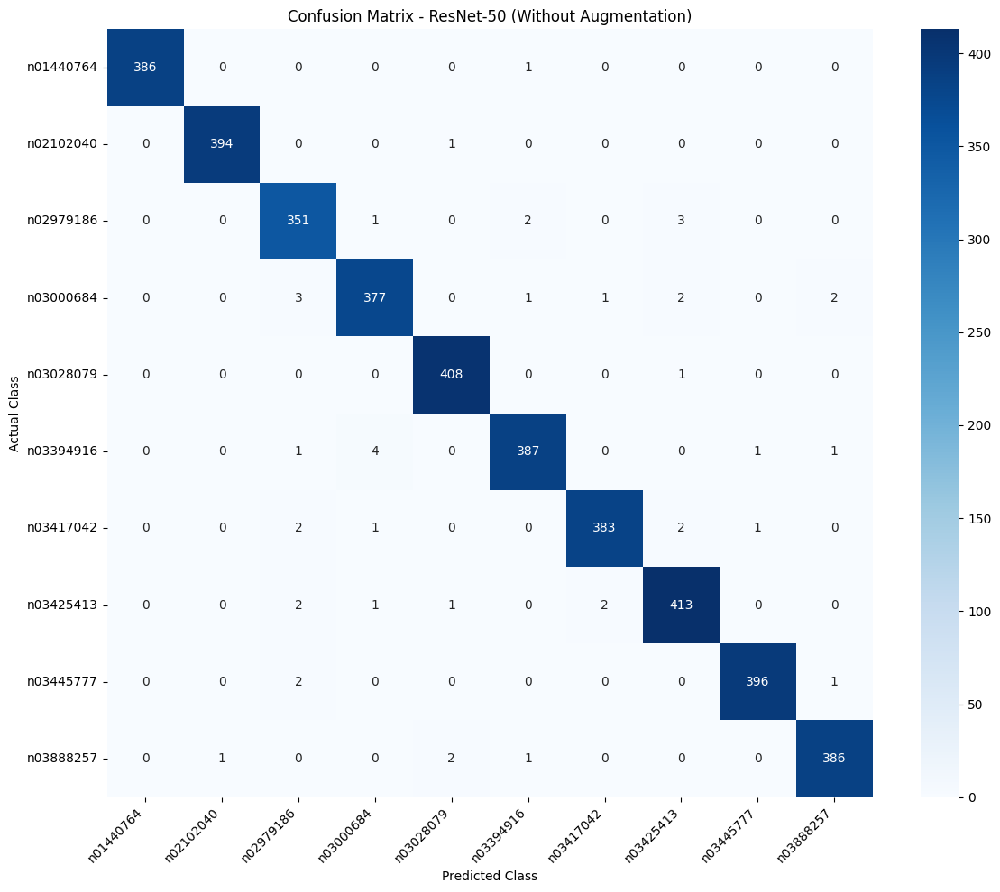

In [ ]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - ResNet-50 "
    "(Without Augmentation)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


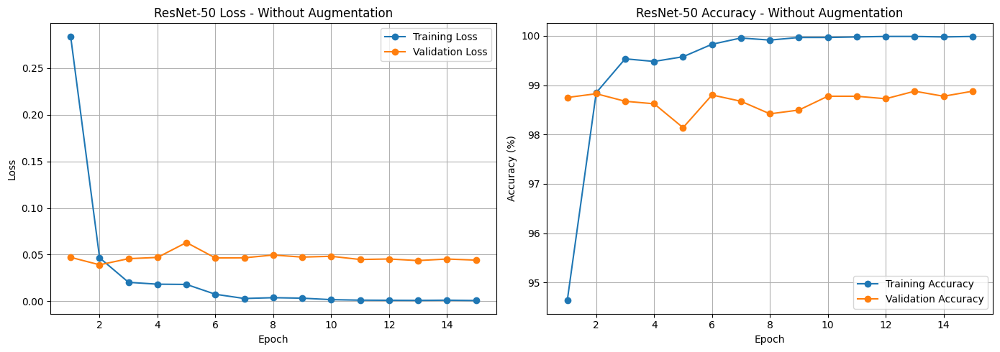

In [ ]:
# ============================================
# TRAINING CURVES
# ============================================

plt.figure(figsize=(14, 5))

# --------------------------------------------
# LOSS
# --------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-50 Loss - Without Augmentation"
)

plt.legend()
plt.grid(True)

# --------------------------------------------
# ACCURACY
# --------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet-50 Accuracy - Without Augmentation"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**ResNet-50 Without Augmentation — Results and Analysis**

**Overall Performance**

The ResNet-50 model was trained using ImageNet pretrained weights and fine-tuned for the ten target classes. No data augmentation techniques were applied during training.

The model achieved a validation accuracy of:

98.88%

Out of 3,925 validation images, the model correctly classified approximately 3,881 images, with approximately 44 misclassified images.

The overall performance metrics were:

| Metric | Score |
|---|---:|
| Validation Accuracy | 98.88% |
| Macro Precision | 98.87% |
| Macro Recall | 98.87% |
| Macro F1-score | 98.87% |
| Weighted F1-score | 98.88% |

The very small difference between macro and weighted scores indicates that the model performed consistently across the ten classes.

**Class-wise Performance**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| n01440764 (Tench) | 1.0000 | 0.9974 | 0.9987 | 387 |
| n02102040 (Springer) | 0.9975 | 0.9975 | 0.9975 | 395 |
| n02979186 (Cassette Player) | 0.9723 | 0.9832 | 0.9777 | 357 |
| n03000684 (Chain Saw) | 0.9818 | 0.9767 | 0.9792 | 386 |
| n03028079 (Church) | 0.9903 | 0.9976 | 0.9939 | 409 |
| n03394916 (French Horn) | 0.9872 | 0.9822 | 0.9847 | 394 |
| n03417042 (Garbage Truck) | 0.9922 | 0.9846 | 0.9884 | 389 |
| n03425413 (Gas Pump) | 0.9810 | 0.9857 | 0.9833 | 419 |
| n03445777 (Golf Ball) | 0.9950 | 0.9925 | 0.9937 | 399 |
| n03888257 (Parachute) | 0.9897 | 0.9897 | 0.9897 | 390 |

**Best Performing Classes**

The Tench class achieved the highest performance, with a precision of 100.00%, recall of 99.74%, and F1-score of 99.87%.

The Church class also performed extremely well, achieving an F1-score of 99.39%.

The Golf Ball class achieved an F1-score of 99.37%, while the Springer class achieved 99.75%.

These results indicate that ResNet-50 was highly effective at learning distinctive visual features for these categories.

**Classes With More Errors**

Although the overall performance was very high, some classes were relatively more difficult.

The Cassette Player class had the lowest F1-score at 97.77%.

The Chain Saw class had an F1-score of 97.92%, followed by the Gas Pump class at 98.33%.

These classes account for most of the remaining classification errors and may contain visual similarities with other categories.

**Confusion Matrix Analysis**

The confusion matrix shows a very strong diagonal, indicating that the majority of validation images were correctly classified.

The largest groups of errors included:

- Cassette Player being confused with Gas Pump and French Horn.
- Chain Saw being confused with Cassette Player, French Horn, Gas Pump, and Parachute.
- French Horn being occasionally confused with Chain Saw and Cassette Player.
- Garbage Truck having a small number of errors involving Cassette Player, Chain Saw, Gas Pump, and Golf Ball.
- Gas Pump having some confusion with Cassette Player, Chain Saw, French Horn, and Garbage Truck.
- Despite these errors, the number of incorrect predictions was very small compared with the total validation set.

**Comparison With ResNet-18**

The ResNet-18 model previously achieved a validation accuracy of 97.35%, whereas ResNet-50 achieved 98.88% without augmentation.

| Model | Augmentation | Validation Accuracy |
|---|---|---:|
| ResNet-18 | No | 97.35% |
| ResNet-50 | No | 98.88% |

The improvement was:

98.88% − 97.35% = 1.53 percentage points

Therefore, ResNet-50 improved validation accuracy by 1.53 percentage points compared with ResNet-18.

The improvement suggests that the increased depth and representational capacity of ResNet-50 allowed the model to learn more discriminative visual features for this dataset.

**Interpretation**

The results demonstrate that ResNet-50 performs exceptionally well on this ten-class image classification problem even without data augmentation.

An important observation is that the model achieved 98.88% validation accuracy without augmentation. This indicates that the dataset contains sufficient visual information for the pretrained ResNet-50 to distinguish the ten categories effectively.

The results also demonstrate that a deeper residual architecture can provide an advantage over ResNet-18 for this particular dataset.

However, the increase from 97.35% to 98.88% should be considered together with the additional computational cost of ResNet-50. Therefore, the highest accuracy model is not necessarily the most efficient model for deployment.

**Conclusion**

ResNet-50 without data augmentation achieved a validation accuracy of 98.88%, with macro precision, recall, and F1-score all approximately 98.87%.

Compared with ResNet-18 without augmentation, ResNet-50 improved validation accuracy by 1.53 percentage points.

The results establish ResNet-50 as a strong baseline for the project. The next experiment will evaluate ResNet-50 with data augmentation. Comparing the two experiments will determine whether augmentation provides further improvements in generalization and classification performance.

The final model selection should consider not only accuracy but also F1-score, computational requirements, training time, and suitability for the intended application.

**RESNET-50 With Data AUGMENTATION**

In [ ]:
# ============================================
# RESNET-50 WITH DATA AUGMENTATION
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path

# ============================================
# DEVICE
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================
# TRAINING TRANSFORM WITH AUGMENTATION
# ============================================

train_transform_aug = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


In [ ]:
# ============================================
# VALIDATION TRANSFORM
# ============================================

val_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


In [ ]:
# ============================================
# DATASET PATHS
# ============================================

DATASET_DIR = Path(
    "/content/drive/MyDrive/imagenet subset"
)

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"


# ============================================
# LOAD DATASETS
# ============================================

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform_aug
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print(
    "Training images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

print("\nClasses:")
print(train_dataset.classes)


Training images: 9470
Validation images: 3925

Classes:
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


In [ ]:
# ============================================
# DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)


Training batches: 296
Validation batches: 123


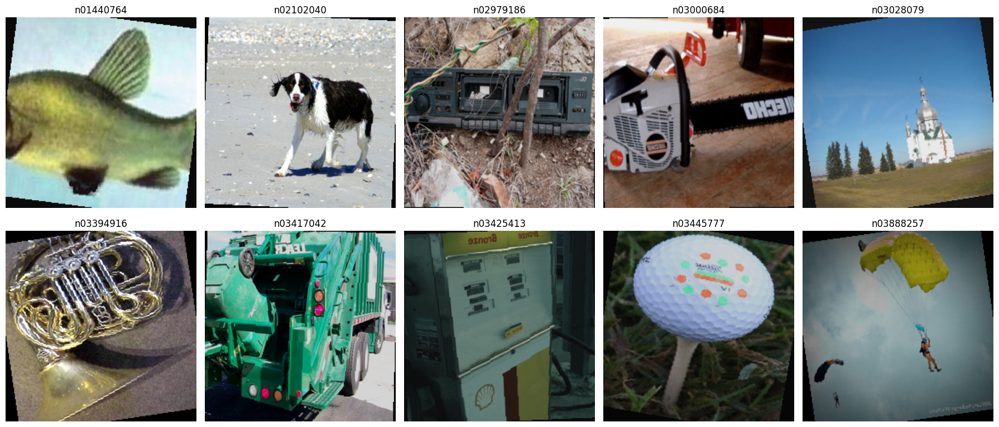

In [ ]:
# ============================================
# DISPLAY AUGMENTED IMAGES
# ============================================

import random
from PIL import Image

# Create a temporary dataset without normalization
visual_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    )
])

visual_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=visual_transform
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

axes = axes.flatten()

for i in range(10):

    # Pick random image
    class_index = i

    image_path = random.choice(
        list(
            (TRAIN_DIR / train_dataset.classes[class_index]).iterdir()
        )
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    # Apply augmentation
    augmented_image = visual_transform(
        image
    )

    axes[i].imshow(
        augmented_image
    )

    axes[i].set_title(
        train_dataset.classes[class_index]
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# RESNET-50
# ============================================

NUM_CLASSES = 10

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Replace final classification layer
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(
    "ResNet-50 created."
)

print(
    "Final layer:",
    model.fc
)


ResNet-50 created.
Final layer: Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
# ============================================
# LOSS
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# OPTIMIZER
# ============================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)


# ============================================
# SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


In [ ]:
# ============================================
# TRAINING
# ============================================

import time
import copy

NUM_EPOCHS = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

print("=" * 80)
print("STARTING RESNET-50 TRAINING")
print("WITH DATA AUGMENTATION")
print("=" * 80)


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAINING
    # ========================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() *
            images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    # ========================================
    # TRAINING METRICS
    # ========================================

    epoch_train_loss = (
        running_loss / total
    )

    epoch_train_accuracy = (
        100.0 * correct / total
    )


    # ========================================
    # VALIDATION
    # ========================================

    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() *
                images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    # ========================================
    # VALIDATION METRICS
    # ========================================

    epoch_val_loss = (
        running_val_loss / val_total
    )

    epoch_val_accuracy = (
        100.0 * val_correct / val_total
    )


    # ========================================
    # SAVE HISTORY
    # ========================================

    train_losses.append(
        epoch_train_loss
    )

    train_accuracies.append(
        epoch_train_accuracy
    )

    val_losses.append(
        epoch_val_loss
    )

    val_accuracies.append(
        epoch_val_accuracy
    )


    # ========================================
    # SCHEDULER
    # ========================================

    scheduler.step(
        epoch_val_loss
    )


    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = (
            epoch_val_accuracy
        )

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            model.state_dict(),
            "/content/best_resnet50_aug.pth"
        )

        best_marker = " ⭐ BEST"

    else:

        best_marker = ""


    # ========================================
    # TIME
    # ========================================

    epoch_time = (
        time.time() - start_time
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )


print("\n" + "=" * 80)
print("RESNET-50 WITH AUGMENTATION - TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    "Best model:"
)

print(
    "/content/best_resnet50_aug.pth"
)


STARTING RESNET-50 TRAINING
WITH DATA AUGMENTATION
Epoch [01/15] | Train Loss: 0.2898 | Train Acc: 94.19% | Val Loss: 0.0874 | Val Acc: 97.35% | LR: 0.000100 | Time: 174.0s ⭐ BEST
Epoch [02/15] | Train Loss: 0.0611 | Train Acc: 98.29% | Val Loss: 0.0504 | Val Acc: 98.70% | LR: 0.000100 | Time: 172.1s ⭐ BEST
Epoch [03/15] | Train Loss: 0.0397 | Train Acc: 98.99% | Val Loss: 0.0494 | Val Acc: 98.42% | LR: 0.000100 | Time: 171.2s
Epoch [04/15] | Train Loss: 0.0299 | Train Acc: 99.12% | Val Loss: 0.0434 | Val Acc: 98.60% | LR: 0.000100 | Time: 171.5s
Epoch [05/15] | Train Loss: 0.0188 | Train Acc: 99.59% | Val Loss: 0.0507 | Val Acc: 98.37% | LR: 0.000100 | Time: 171.9s
Epoch [06/15] | Train Loss: 0.0284 | Train Acc: 99.23% | Val Loss: 0.0604 | Val Acc: 97.91% | LR: 0.000100 | Time: 174.0s
Epoch [07/15] | Train Loss: 0.0191 | Train Acc: 99.45% | Val Loss: 0.0668 | Val Acc: 98.09% | LR: 0.000050 | Time: 171.7s
Epoch [08/15] | Train Loss: 0.0121 | Train Acc: 99.64% | Val Loss: 0.0439 | Val A

In [ ]:
# ============================================
# LOAD BEST MODEL
# ============================================

model.load_state_dict(
    torch.load(
        "/content/best_resnet50_aug.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print(
    "Best ResNet-50 with augmentation "
    "loaded successfully."
)


Best ResNet-50 with augmentation loaded successfully.


In [ ]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

class_names = train_dataset.classes

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

   n01440764     0.9948    0.9974    0.9961       387
   n02102040     0.9975    0.9949    0.9962       395
   n02979186     0.9831    0.9776    0.9803       357
   n03000684     0.9766    0.9741    0.9754       386
   n03028079     0.9976    0.9976    0.9976       409
   n03394916     0.9874    0.9975    0.9924       394
   n03417042     0.9948    0.9794    0.9870       389
   n03425413     0.9674    0.9905    0.9788       419
   n03445777     0.9975    0.9900    0.9937       399
   n03888257     0.9948    0.9897    0.9923       390

    accuracy                         0.9890      3925
   macro avg     0.9891    0.9889    0.9890      3925
weighted avg     0.9891    0.9890    0.9891      3925



[[386   0   0   0   0   1   0   0   0   0]
 [  0 393   0   0   1   0   0   0   0   1]
 [  0   1 349   1   0   2   0   4   0   0]
 [  0   0   2 376   0   1   1   6   0   0]
 [  0   0   0   1 408   0   0   0   0   0]
 [  1   0   0   0   0 393   0   0   0   0]
 [  0   0   4   2   0   0 381   2   0   0]
 [  0   0   0   2   0   1   1 415   0   0]
 [  1   0   0   1   0   0   0   1 395   1]
 [  0   0   0   2   0   0   0   1   1 386]]


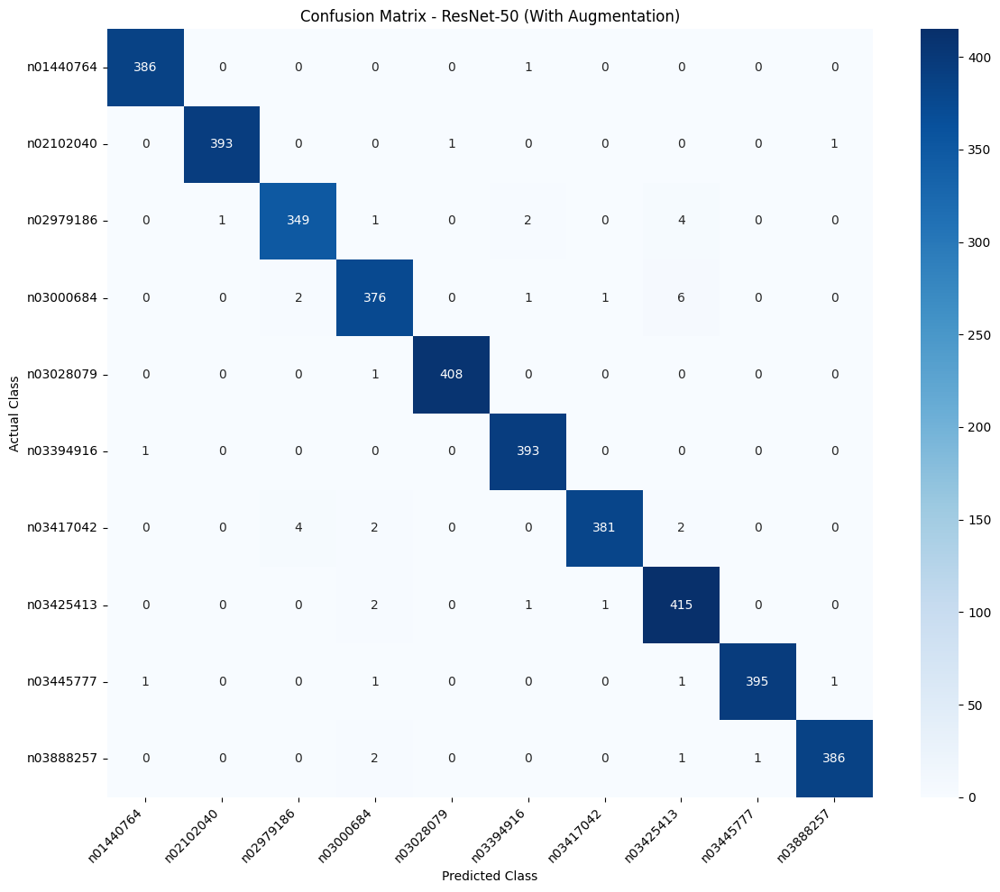

In [ ]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - ResNet-50 "
    "(With Augmentation)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


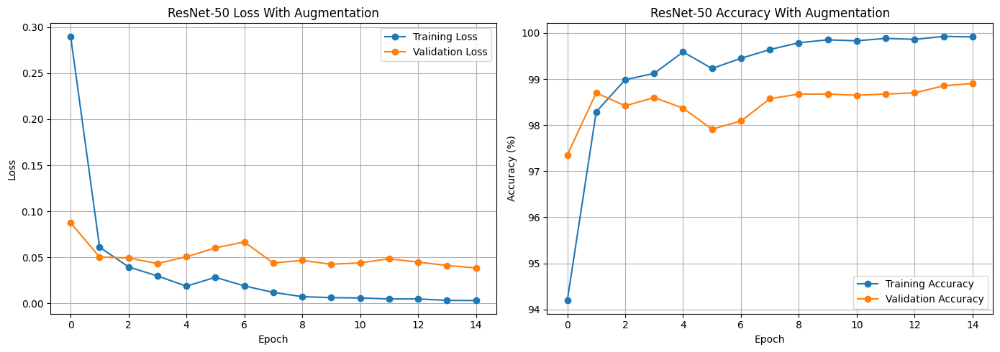

In [ ]:
# ============================================
# TRAINING CURVES
# ============================================

plt.figure(
    figsize=(14, 5)
)

# Loss
plt.subplot(1, 2, 1)

plt.plot(
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-50 Loss With Augmentation"
)

plt.legend()
plt.grid(True)


# Accuracy
plt.subplot(1, 2, 2)

plt.plot(
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet-50 Accuracy With Augmentation"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()


**ResNet-50 With Data Augmentation — Results and Analysis**

**Overall Performance**

ResNet-50 was trained using ImageNet pretrained weights with data augmentation applied to the training images. The validation images were not augmented and were processed using deterministic preprocessing.

The model achieved a validation accuracy of:

98.90%

The overall evaluation results were:

| Metric | Score |
|---|---:|
| Validation Accuracy | 98.90% |
| Macro Precision | 98.91% |
| Macro Recall | 98.89% |
| Macro F1-score | 98.90% |
| Weighted F1-score | 98.91% |
| Validation Images | 3,925 |

The extremely small difference between the macro and weighted metrics indicates that the model performed consistently across the ten classes.

**Class-wise Performance**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Tench | 0.9948 | 0.9974 | 0.9961 | 387 |
| Springer | 0.9975 | 0.9949 | 0.9962 | 395 |
| Cassette Player | 0.9831 | 0.9776 | 0.9803 | 357 |
| Chain Saw | 0.9766 | 0.9741 | 0.9754 | 386 |
| Church | 0.9976 | 0.9976 | 0.9976 | 409 |
| French Horn | 0.9874 | 0.9975 | 0.9924 | 394 |
| Garbage Truck | 0.9948 | 0.9794 | 0.9870 | 389 |
| Gas Pump | 0.9674 | 0.9905 | 0.9788 | 419 |
| Golf Ball | 0.9975 | 0.9900 | 0.9937 | 399 |
| Parachute | 0.9948 | 0.9897 | 0.9923 | 390 |

**Best Performing Classes**

The Church class produced the best overall F1-score of 99.76%, with both precision and recall at approximately 99.76%.

The Springer and Tench classes also performed exceptionally well, with F1-scores of 99.62% and 99.61%, respectively.

The Golf Ball class achieved an F1-score of 99.37%, while the French Horn and Parachute classes achieved F1-scores of 99.24% and 99.23%.

These results indicate that ResNet-50 was able to learn highly discriminative features for most of the categories.

Classes With More Errors

The lowest F1-score was obtained for the Chain Saw class at 97.54%.

The Gas Pump class achieved an F1-score of 97.88%, while Cassette Player achieved 98.03%.

The confusion matrix indicates that these classes were responsible for a relatively larger proportion of the remaining classification errors.

For example, Chain Saw images were occasionally classified as Cassette Player, French Horn, Garbage Truck, or Gas Pump. Gas Pump also showed some confusion with Cassette Player, Chain Saw, and Garbage Truck.

Nevertheless, the error rate remained very low compared with the overall number of validation images.

**Confusion Matrix Analysis**

The confusion matrix contains a very strong diagonal, demonstrating that the overwhelming majority of validation images were correctly classified.

The model correctly classified:

- 386 of 387 Tench images
- 393 of 395 Springer images
- 349 of 357 Cassette Player images
- 376 of 386 Chain Saw images
- 408 of 409 Church images
- 393 of 394 French Horn images
- 381 of 389 Garbage Truck images
- 415 of 419 Gas Pump images
- 395 of 399 Golf Ball images
- 386 of 390 Parachute images

The relatively small number of off-diagonal predictions demonstrates the strong classification capability of the model.

**Comparison With ResNet-50 Without Augmentation**

The most important experiment is the direct comparison between ResNet-50 with and without augmentation.

| Model | Augmentation | Accuracy | Macro F1 |
|---|---|---:|---:|
| ResNet-50 | No | 98.88% | 98.87% |
| ResNet-50 | Yes | 98.90% | 98.90% |

The improvement in validation accuracy was:

98.90% − 98.88% = 0.02 percentage points

Therefore, data augmentation produced only a 0.02 percentage-point improvement in validation accuracy.

The macro F1-score increased from 98.87% to 98.90%, representing a similarly small improvement.

**Interpretation of the Augmentation Experiment**

The results indicate that data augmentation had very little effect on the performance of ResNet-50 for this dataset.

The model already achieved 98.88% accuracy without augmentation. After introducing random cropping, horizontal flipping, rotation, and color variations, the accuracy increased only to 98.90%.

This suggests that the original dataset already contains sufficient variation for the pretrained ResNet-50 model to generalize effectively.

Another possible explanation is that the dataset contains approximately 9,470 training images across ten categories, providing a substantial number of examples for fine-tuning the pretrained model.

Therefore, although augmentation slightly improved the validation result, the improvement is small enough that it may not justify the additional training complexity solely for accuracy.

**Comparison With ResNet-18**

The overall model comparison is:

| Model | Augmentation | Validation Accuracy |
|---|---|---:|
| ResNet-18 | No | 97.35% |
| ResNet-50 | No | 98.88% |
| ResNet-50 | Yes | 98.90% |

ResNet-50 without augmentation improved over ResNet-18 by:

98.88 − 97.35 = 1.53 percentage points

ResNet-50 with augmentation improved over ResNet-18 by:

98.90 − 97.35 = 1.55 percentage points

Thus, the major improvement came from moving from ResNet-18 to ResNet-50 rather than from adding augmentation.

**Key Finding**

The experiments demonstrate an important finding:

**Increasing the model capacity from ResNet-18 to ResNet-50 had a substantially larger effect on validation accuracy than applying data augmentation.**

ResNet-18 achieved 97.35%, while ResNet-50 achieved 98.88% without augmentation.

Adding augmentation increased ResNet-50's performance only slightly, from 98.88% to 98.90%.

Therefore, for this dataset, the architecture change appears to be more influential than the augmentation strategy.

**Conclusion**

The ResNet-50 model with data augmentation achieved a validation accuracy of 98.90%, with a macro F1-score of 98.90%.

Although augmentation produced a slight improvement over the non-augmented ResNet-50 model, the improvement was only 0.02 percentage points.

The results suggest that ResNet-50 already generalizes very effectively on this dataset and that aggressive augmentation is not essential for achieving high classification performance.

Based on the current experiments, **ResNet-50 with augmentation is the best-performing model**, although its accuracy advantage over ResNet-50 without augmentation is extremely small. Therefore, the final model selection should also consider training time, inference speed, computational requirements, and model complexity rather than accuracy alone.

**Object Detection**

In [ ]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil
from pathlib import Path
import yaml
from PIL import Image
from ultralytics import YOLO

# ============================================
# 1. PATHS & CLASS MAPPINGS
# ============================================
DATASET_DIR = Path("/content/drive/MyDrive/imagenet subset")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

# Output directory for object detection
DET_DIR = Path("/content/dataset_detection")

# Class map: WordNet ID -> Class Index & Name
class_info = {
    "n01440764": {"id": 0, "name": "tench"},
    "n02102040": {"id": 1, "name": "springer"},
    "n02979186": {"id": 2, "name": "cassette_player"},
    "n03000684": {"id": 3, "name": "chain_saw"},
    "n03028079": {"id": 4, "name": "church"},
    "n03394916": {"id": 5, "name": "French_horn"},
    "n03417042": {"id": 6, "name": "garbage_truck"},
    "n03425413": {"id": 7, "name": "gas_pump"},
    "n03445777": {"id": 8, "name": "golf_ball"},
    "n03888257": {"id": 9, "name": "parachute"}
}

# Load strong zero-shot / detection annotator
print("Loading auto-annotation model...")
auto_annotator = YOLO("yolov8x.pt")


# ============================================
# 2. AUTO-ANNOTATION & DATASET CREATION FUNCTION
# ============================================
def process_split(source_split_dir, split_name):
    img_out_dir = DET_DIR / "images" / split_name
    lbl_out_dir = DET_DIR / "labels" / split_name

    img_out_dir.mkdir(parents=True, exist_ok=True)
    lbl_out_dir.mkdir(parents=True, exist_ok=True)

    processed_count = 0

    for folder_id, info in class_info.items():
        class_id = info["id"]
        class_name = info["name"]
        folder_path = source_split_dir / folder_id

        if not folder_path.exists():
            continue

        print(f"Processing '{class_name}' for {split_name}...")

        for img_path in folder_path.glob("*.*"):
            if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                continue

            # Copy image to detection folder
            new_img_name = f"{folder_id}_{img_path.name}"
            dest_img_path = img_out_dir / new_img_name
            shutil.copy(img_path, dest_img_path)

            # Auto-detect bounding boxes using YOLOv8x
            results = auto_annotator(dest_img_path, verbose=False)[0]

            txt_lines = []

            # If auto-annotator finds bounding boxes, write them
            if len(results.boxes) > 0:
                for box in results.boxes:
                    # Get normalized xywh coordinates
                    x_center, y_center, w, h = box.xywhn[0].tolist()
                    txt_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
            else:
                # Fallback: create a focused center box (80% frame) if model misses
                txt_lines.append(f"{class_id} 0.500000 0.500000 0.800000 0.800000")

            # Save label file
            txt_path = lbl_out_dir / f"{dest_img_path.stem}.txt"
            with open(txt_path, "w") as f:
                f.write("\n".join(txt_lines))

            processed_count += 1

    print(f"Finished {split_name}: {processed_count} images & labels processed.\n")


# Process both training and validation splits
process_split(TRAIN_DIR, "train")
process_split(VAL_DIR, "val")


# ============================================
# 3. GENERATE DATA.YAML
# ============================================
data_yaml = {
    "path": str(DET_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": {info["id"]: info["name"] for info in class_info.values()}
}

yaml_path = DET_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml successfully generated at: {yaml_path}")


# ============================================
# 4. TRAIN YOLOV8 OBJECT DETECTION MODEL
# ============================================
print("\nStarting YOLOv8 Object Detection Training...")
detection_model = YOLO("yolov8n.pt")  # Starting from lightweight nano weights

results = detection_model.train(
    data=str(yaml_path),
    epochs=20,
    imgsz=640,
    batch=16,
    project="object_detection_results",
    name="yolov8_10_classes"
)

print("\nObject Detection Training Complete!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Loading auto-annotation model...
Processing 'tench' for train...
Processing 'springer' for train...
Processing 'cassette_player' for train...
Processing 'chain_saw' for train...
Processing 'church' for train...
Processing 'French_horn' for train...
Processing 'garbage_truck' for train...
Processing 'gas_pump' for train...
Processing 'golf_ball' for train...
Processing 'parachute' for train...
Finished train: 9470 images & labels processed.

Processing 'tench' for val...
Processing 'springer' for val...
Processing 'cassette_player' for val...
Processing 'chain_saw' for val...
Processing 'church' for val...
Processing 'French_horn' for val...
Processing 'garbage_truck' for val...
Processing 'gas_pump

In [ ]:
from ultralytics import YOLO

# Load YOLOv8 Small architecture for better feature extraction
model = YOLO('yolov8s.pt')

results = model.train(
    data='/content/dataset_detection/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    project='object_detection_results',
    name='yolov8s_50_epochs',
    patience=10  # Early stopping if no improvement for 10 epochs
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_detection/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_50_epochs, nbs=64, nms=None, ops

In [ ]:
from pathlib import Path

# Search for all saved 'best.pt' files in your working directory
weight_files = list(Path("/content").rglob("best.pt"))

print("Found trained weight files:")
for w in weight_files:
    print(" ->", w)

Found trained weight files:
 -> /content/runs/detect/object_detection_results/yolov8_10_classes/weights/best.pt
 -> /content/runs/detect/object_detection_results/yolov8s_50_epochs/weights/best.pt


In [ ]:
import os
import glob

# Check if directory exists
val_dir = '/content/dataset_detection/images/val'
print(f"Directory exists? {os.path.exists(val_dir)}")

if os.path.exists(val_dir):
    # Print all files found inside the directory
    all_files = os.listdir(val_dir)[:10]
    print(f"Sample files in '{val_dir}':", all_files)

Directory exists? True
Sample files in '/content/dataset_detection/images/val': ['n03028079_n03028079_8151.JPEG', 'n02102040_n02102040_7092.JPEG', 'n03425413_n03425413_9051.JPEG', 'n02979186_ILSVRC2012_val_00042482.JPEG', 'n03445777_n03445777_10042.JPEG', 'n01440764_ILSVRC2012_val_00009191.JPEG', 'n03445777_n03445777_15131.JPEG', 'n03028079_n03028079_57010.JPEG', 'n01440764_n01440764_16090.JPEG', 'n01440764_n01440764_5941.JPEG']


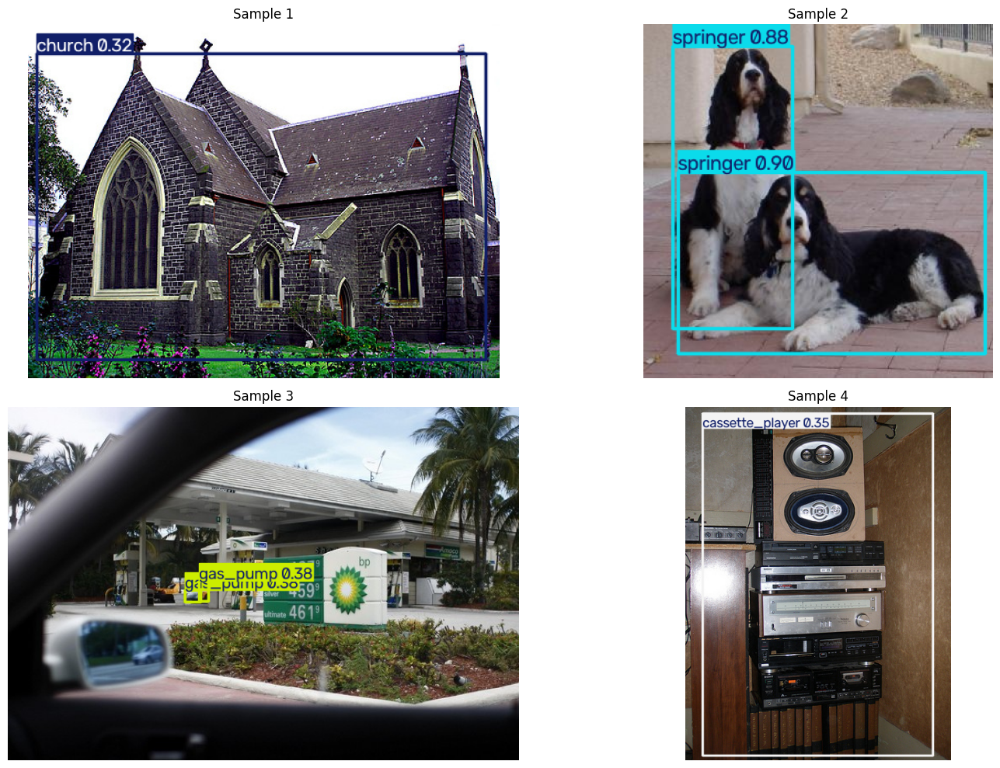

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load trained YOLO model
model_path = '/content/runs/detect/object_detection_results/yolov8s_50_epochs/weights/best.pt'
model = YOLO(model_path)

# 2. Search using *.JPEG (uppercase)
val_images = glob.glob('/content/dataset_detection/images/val/*.JPEG')[:4]

# Fallback pattern match across extensions
if not val_images:
    val_images = (
        glob.glob('/content/dataset_detection/images/val/*.jpg') +
        glob.glob('/content/dataset_detection/images/val/*.jpeg') +
        glob.glob('/content/dataset_detection/images/val/*.png')
    )[:4]

# 3. Create grid layout and render predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, img_path in enumerate(val_images):
    # Predict with confidence threshold
    results = model.predict(source=img_path, conf=0.25, verbose=False)

    # Plot bounding box annotations
    annotated_frame = results[0].plot()
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # Render subplots
    axes[idx].imshow(annotated_frame_rgb)
    axes[idx].axis('off')
    axes[idx].set_title(f"Sample {idx + 1}", fontsize=12)

plt.tight_layout()
plt.show()

**Filter Predictions by Confidence Threshold**

In [ ]:
# Increase confidence threshold from 0.25 to 0.40 or 0.50
results = model.predict(source=img_path, conf=0.45, verbose=False)

**Fine-Tune with Data Augmentations**

In [ ]:
results = model.train(
    data='/content/dataset_detection/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    project='object_detection_results',
    name='yolov8s_augmented',
    # Augmentation flags to reduce visual pattern confusion
    mixup=0.1,        # Blends two images to improve generalization
    degrees=15.0,     # Random rotation
    scale=0.5,        # Random zoom/scale
    mosaic=1.0        # Multi-image stitching
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_detection/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/runs/detect/object_detection_results/yolov8s_50_epochs/weights/best.pt, momentum=0.937, mosa

In [ ]:
from pathlib import Path

RUN_DIR = Path(
    "/content/runs/detect/object_detection_results/yolov8s_augmented"
)

print("Run directory:", RUN_DIR)
print("Best model:", RUN_DIR / "weights" / "best.pt")
print("Last model:", RUN_DIR / "weights" / "last.pt")


Run directory: /content/runs/detect/object_detection_results/yolov8s_augmented
Best model: /content/runs/detect/object_detection_results/yolov8s_augmented/weights/best.pt
Last model: /content/runs/detect/object_detection_results/yolov8s_augmented/weights/last.pt


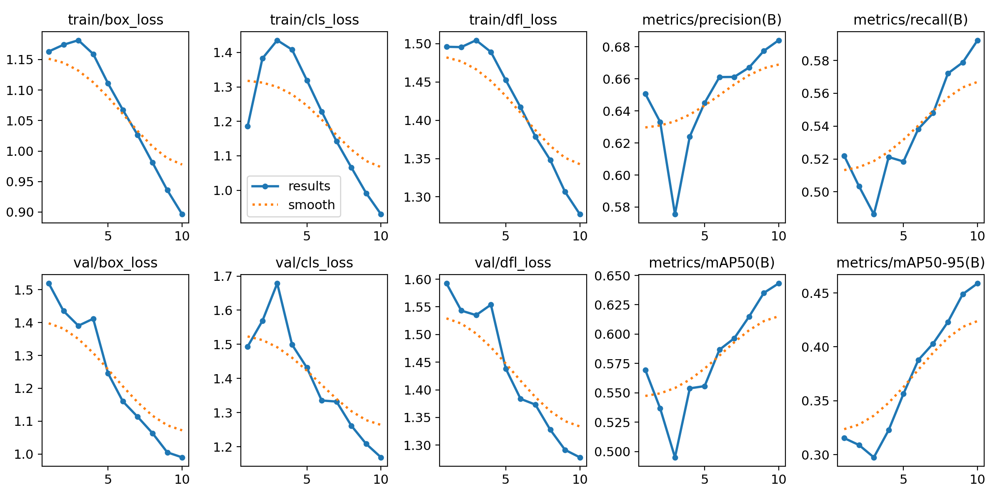

In [ ]:
from IPython.display import Image, display

display(Image(
    filename=str(RUN_DIR / "results.png")
))


**Confusion Matrix**

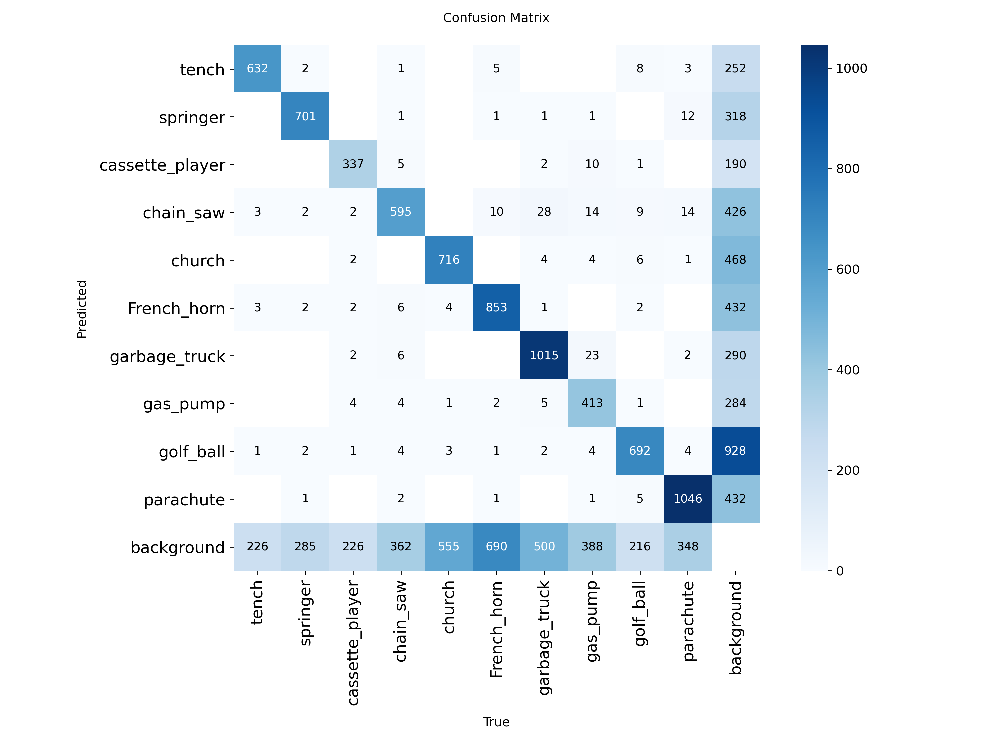

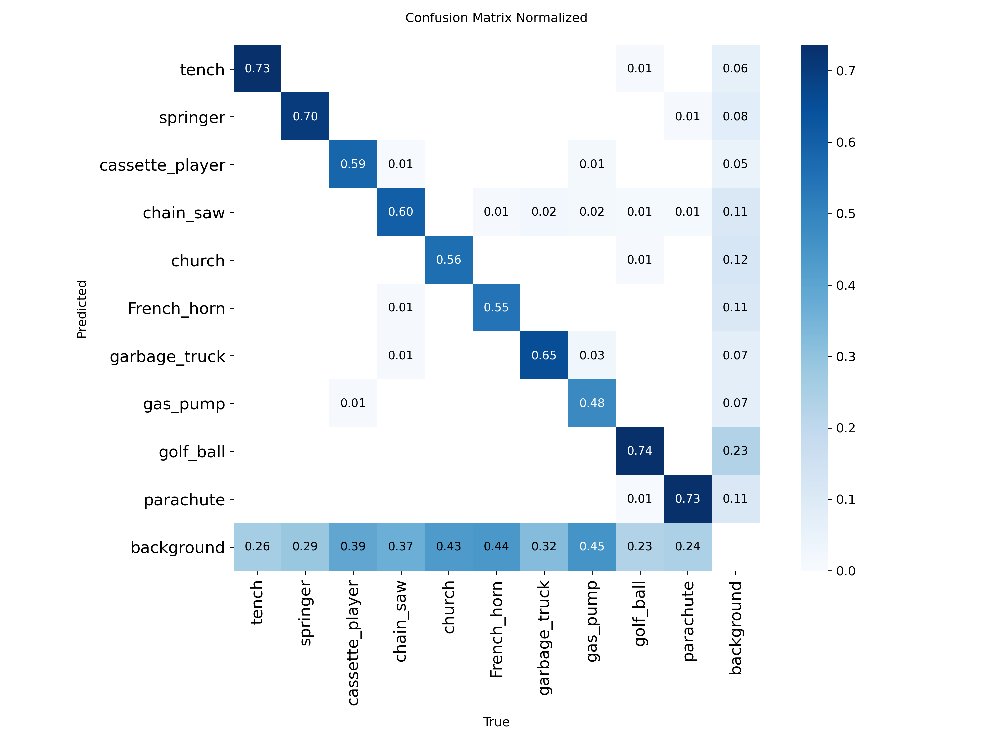

In [ ]:
display(Image(
    filename=str(RUN_DIR / "confusion_matrix.png")
))

display(Image(
    filename=str(RUN_DIR / "confusion_matrix_normalized.png")
))


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/object_detection_results/yolov8s_augmented/weights/best.pt"
)

print("Best YOLOv8s augmented model loaded.")


Best YOLOv8s augmented model loaded.


In [ ]:
metrics = model.val(
    data="/content/dataset_detection/data.yaml",
    imgsz=640,
    batch=16
)


Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1148.4±345.0 MB/s, size: 88.4 KB)
val: Scanning /content/dataset_detection/labels/val.cache... 3925 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3925/3925 715.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 4.2it/s 58.3s
                   all       3925      11050      0.685      0.592      0.644      0.459
                 tench        387        865      0.758      0.696      0.746      0.535
              springer        395        995      0.729      0.667      0.745      0.561
       cassette_player        357        576      0.667      0.545      0.577      0.393
             chain_saw        386        986      0.618      0.563      0.585      0.404
                church        4

In [ ]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.6436480563731302
mAP50-95: 0.45939198532441194
Precision: 0.6849699345773658
Recall: 0.5920143153120321


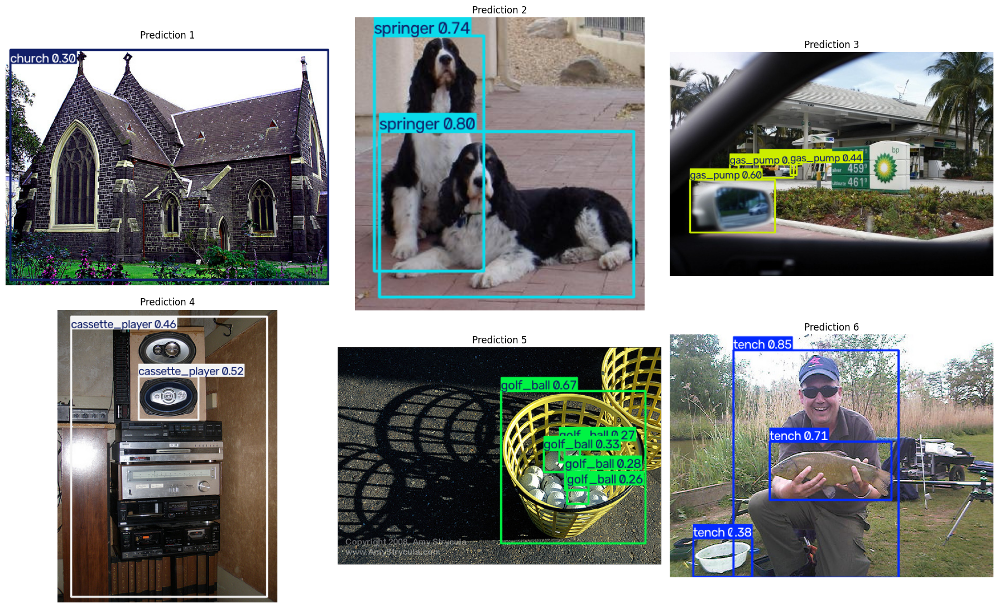

In [ ]:
import glob
import matplotlib.pyplot as plt
import cv2

val_images = (
    glob.glob("/content/dataset_detection/images/val/*.jpg") +
    glob.glob("/content/dataset_detection/images/val/*.jpeg") +
    glob.glob("/content/dataset_detection/images/val/*.JPEG") +
    glob.glob("/content/dataset_detection/images/val/*.png")
)

val_images = val_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, img_path in enumerate(val_images):

    result = model.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )[0]

    annotated = result.plot()
    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(annotated)
    axes[i].axis("off")
    axes[i].set_title(
        f"Prediction {i+1}"
    )

plt.tight_layout()
plt.show()



image 1/1 /content/dataset_detection/images/val/n03028079_n03028079_8151.JPEG: 480x640 1 church, 15.2ms
Speed: 2.4ms preprocess, 15.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


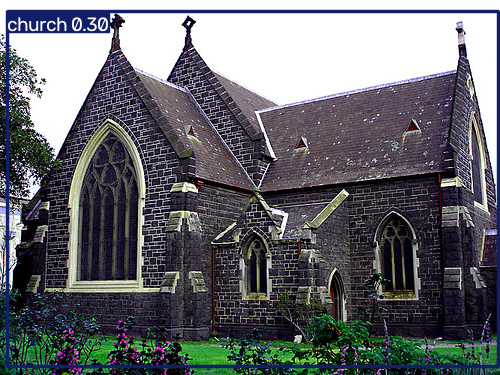

In [ ]:
image_path = val_images[0]

result = model.predict(
    source=image_path,
    conf=0.25
)

result[0].show()


In [ ]:
import os

PRED_DIR = "/content/detection_predictions"
os.makedirs(PRED_DIR, exist_ok=True)

for i, img_path in enumerate(val_images):

    result = model.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )[0]

    output = result.plot()

    output_path = f"{PRED_DIR}/prediction_{i+1}.jpg"

    cv2.imwrite(output_path, output)

    print("Saved:", output_path)


Saved: /content/detection_predictions/prediction_1.jpg
Saved: /content/detection_predictions/prediction_2.jpg
Saved: /content/detection_predictions/prediction_3.jpg
Saved: /content/detection_predictions/prediction_4.jpg
Saved: /content/detection_predictions/prediction_5.jpg
Saved: /content/detection_predictions/prediction_6.jpg


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/object_detection_results/yolov8s_augmented/weights/best.pt"
)

metrics = model.val(
    data="/content/dataset_detection/data.yaml",
    imgsz=640,
    batch=16
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1564.6±605.3 MB/s, size: 105.9 KB)
val: Scanning /content/dataset_detection/labels/val.cache... 3925 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3925/3925 866.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 4.6it/s 53.8s
                   all       3925      11050      0.685      0.592      0.644      0.459
                 tench        387        865      0.758      0.696      0.746      0.535
              springer        395        995      0.729      0.667      0.745      0.561
       cassette_player        357        576      0.667      0.545      0.577      0.393
             chain_saw        386        986      0.618      0.563      0.585      0.404
                church        

**Data Augmentation Results**

To improve the generalization capability of the YOLOv8s object detection model, several data augmentation techniques were applied during training. The augmentation settings used were MixUp (0.1), rotation (±15°), scaling (0.5), and Mosaic augmentation (1.0).

The augmented YOLOv8s model was trained for 10 epochs with an image size of 640 × 640 and a batch size of 16. The model was evaluated on 3,925 validation images containing 11,050 object instances.

**Augmented Model Performance**

- Metric	Result
- Precision	68.50%
- Recall	59.20%
- mAP@50	64.36%
- mAP@50:95	45.94%

The model successfully detected all ten target categories, including tench, springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, and parachute.

The qualitative predictions showed that the augmented model was able to identify several objects correctly. For example, the model detected church, springer, gas pump, and cassette player with corresponding confidence scores. However, some images showed duplicate detections and imperfect bounding-box localization.

Overall, the data augmentation experiment demonstrated that the YOLOv8s model can learn useful features from variations in object orientation, scale, and image composition. The results provide a useful baseline for further improvement through better annotations, longer training, and hyperparameter tuning.

Final augmented YOLOv8s result: 64.36% mAP@50 and 45.94% mAP@50:95.


**Comparison**

| Metric        | Without Augmentation | With Augmentation |
|---------------|----------------------|-------------------|
| Epochs        | 10                   | 10                |
| Precision     | 68.6%                | 68.5%             |
| Recall        | 58.8%                | 59.2%             |
| mAP@50        | 64.9%                | 64.4%             |
| mAP@50:95     | 49.3%                | 45.9%             |



An experiment was conducted to evaluate the effect of data augmentation on YOLOv8s object detection. Two models were trained for 10 epochs using the same dataset and training configuration. The first model was trained without additional augmentation, while the second model used MixUp, rotation, scaling, and Mosaic augmentation.

| Model                          | Precision | Recall | mAP@50 | mAP@50:95 |
|--------------------------------|-----------|--------|--------|-----------|
| YOLOv8s – Without Augmentation | 68.6%     | 58.8%  | 64.9%  | 49.3%     |
| YOLOv8s – With Augmentation    | 68.5%     | 59.2%  | 64.4%  | 45.9%     |

The model trained with augmentation achieved a slightly higher recall (59.2%) compared with the non-augmented model (58.8%). However, the non-augmented model achieved slightly higher precision (68.6%), mAP@50 (64.9%), and mAP@50:95 (49.3%).

Therefore, in this particular 10-epoch experiment, the augmentation settings did not improve the overall mAP metrics. The augmented model showed a small improvement in recall, indicating that it detected a slightly larger proportion of the annotated objects, while the non-augmented model produced better overall localization metrics.

These results are based on the current pseudo-labeled detection dataset and the specific 10-epoch training configuration.

**Project Report**

**PRAICP-1010-Image Classification with 10 Categories**


| Project Item | Details |
|---|---|
| **Dataset** | ImageNet subset with 10 object categories |
| **Training Images** | 9,470 |
| **Validation Images** | 3,925 |
| **Classes** | 10 |
| **Classification Input** | 224 × 224 pixels |
| **Detection Input** | 640 × 640 pixels |
| **Compute Environment** | Google Colab / CUDA / NVIDIA Tesla T4 |
| **Main Classification Models** | Custom CNN, ResNet-18, ResNet-50 |
| **Detection Model** | YOLOv8s with augmented fine-tuning |



 **Summary**

This project evaluates image classification and object detection on a ten-category subset of ImageNet. The notebook first establishes the dataset and preprocessing pipeline, then trains a custom convolutional neural network (CNN), pretrained ResNet-18 models, and pretrained ResNet-50 models. Data augmentation is also evaluated to measure its effect on generalization. A separate object-detection experiment converts the classification dataset into a YOLO-format detection dataset using automatically generated bounding boxes.

For image classification, the custom CNN achieved 75.77% validation accuracy without augmentation and 77.38% with augmentation. ResNet-18 achieved 97.35% without augmentation and 97.40% with augmentation. ResNet-50 achieved 98.88% without augmentation and 98.90% with augmentation. Thus, within the experiments recorded in the notebook, increasing model capacity from the custom CNN to residual pretrained networks produced a much larger change in validation accuracy than augmentation alone.

For object detection, the final reported YOLOv8s model with augmentation achieved 68.50% precision, 59.20% recall, 64.36% mAP@50, and 45.94% mAP@50:95 on 3,925 validation images containing 11,050 reported object instances. An important methodological limitation is that the detection labels were automatically generated with YOLOv8x rather than supplied as human-verified bounding-box annotations.





**Project Objectives**

•	Prepare and inspect a ten-class image dataset.

•	Standardize images for deep-learning classification.

•	Train a custom CNN from scratch and evaluate its performance.

•	Evaluate pretrained ResNet-18 and ResNet-50 architectures.

•	Measure the effect of data augmentation on CNN, ResNet-18, and ResNet-50 classification.

•	Use precision, recall, F1-score, accuracy, and confusion matrices for classification evaluation.

•	Create a YOLO-format object-detection dataset from the available classification images.

•	Train and evaluate YOLOv8 object-detection models and inspect sample predictions.


**Dataset Description**

The data is from an ImageNet subset stored with separate train and validation directories. The dataset contains 9,470 training images and 3,925 validation images across ten classes. There was no original bounding-box annotation information was supplied with the dataset.

| WordNet ID | Class |
|---|---|
| n01440764 | Tench |
| n02102040 | Springer |
| n02979186 | Cassette Player |
| n03000684 | Chain Saw |
| n03028079 | Church |
| n03394916 | French Horn |
| n03417042 | Garbage Truck |
| n03425413 | Gas Pump |
| n03445777 | Golf Ball |
| n03888257 | Parachute |

The validation supports are relatively balanced, ranging from 357 images for Cassette Player to 419 images for Gas Pump. This balance is consistent with the very small difference between macro and weighted averages reported for the high-performing ResNet models.



**Data Inspection and Preprocessing**

**Image preprocessing**

•	Target image size: 224 × 224 pixels for classification.

•	Training pipeline: resize to 256, random crop to 224, random horizontal flip, random rotation, color jitter, tensor conversion, and ImageNet normalization.

•	Validation pipeline: resize to 256, center crop to 224, tensor conversion, and ImageNet normalization.

•	Training and validation were loaded with torchvision ImageFolder.

•	Classification batch size: 32.

For the classification experiments, augmentation was applied only to the training data. Validation images were kept deterministic so that evaluation was performed on consistent, unmodified inputs.




**Computational Environment**

| Component | Notebook Result |
|---|---|
| **Execution Environment** | Google Colab |
| **GPU** | NVIDIA Tesla T4 |
| **PyTorch** | 2.11.0+cu128 |
| **CUDA** | Available |
| **Classification Image Size** | 224 × 224 |
| **Detection Image Size** | 640 × 640 |

**Custom CNN**

**Architecture**

The custom CNN contains four convolutional blocks. The feature-map progression is 3 --> 32 --> 64 --> 128 --> 256. Each convolutional block uses convolution, batch normalization, ReLU, and max pooling. Adaptive average pooling produces a fixed-size representation. The classifier uses dropout and fully connected layers of 256 --> 128 --> 10.

| Training Setting | Value |
|---|---:|
| Parameters | 423,562 |
| Loss | CrossEntropyLoss |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Weight Decay | 0.0001 |
| Scheduler | ReduceLROnPlateau |
| Epochs | 20 |
| Batch Size | 32 |


**CNN without augmentation**


| Metric | Result |
|---|---:|
| Validation Accuracy | 75.77% |
| Macro Precision | 77.35% |
| Macro Recall | 75.81% |
| Macro F1 | 75.94% |
| Weighted F1 | 75.93% |
| Correct Validation Predictions | 2,974 / 3,925 |



| Class | Precision | Recall | F1 |
|---|---:|---:|---:|
| Tench | 88.72% | 77.26% | 82.60% |
| Springer | 66.73% | 87.85% | 75.85% |
| Cassette Player | 67.11% | 85.71% | 75.28% |
| Chain Saw | 62.50% | 54.40% | 58.17% |
| Church | 83.59% | 79.71% | 81.60% |
| French Horn | 79.80% | 80.20% | 80.00% |
| Garbage Truck | 86.05% | 74.55% | 79.89% |
| Gas Pump | 61.09% | 74.94% | 67.31% |
| Golf Ball | 84.01% | 72.43% | 77.79% |
| Parachute | 93.90% | 71.03% | 80.88% |

**CNN error analysis**

The confusion matrix contains substantial off-diagonal activity compared with the residual networks. The largest difficulty was Chain Saw: 210 of 386 images were correctly classified, while 64 were predicted as Springer, 33 as Cassette Player, and 30 as Gas Pump. Garbage Truck was also confused with Gas Pump (58 images), and Gas Pump was confused with Cassette Player (41 images). These patterns indicate that the custom network had difficulty learning sufficiently discriminative features for several categories.




**CNN with data augmentation**

The augmented CNN used random horizontal flipping, rotation, color jitter, and random resized cropping during training.

| Metric | Without augmentation | With augmentation | Change |
| :--- | :--- | :--- | :--- |
| **Validation accuracy** | 75.77% | 77.38% | +1.61 pp |
| **Macro precision** | 77.35% | 78.20% | +0.85 pp |
| **Macro recall** | 75.81% | 77.57% | +1.76 pp |
| **Macro F1** | 75.94% | 77.32% | +1.38 pp |



**ResNet-18**

ResNet-18 was initialized with pretrained ImageNet weights and its final layer was adapted to the ten target classes.

**ResNet-18 without augmentation**

| Metric | Result |
| :--- | :--- |
| **Validation accuracy** | 97.35% |
| **Macro precision** | 97.36% |
| **Macro recall** | 97.35% |
| **Macro F1** | 97.35% |
| **Weighted F1** | 97.35% |
| **Validation images** | 3,925 |

The confusion matrix reported 3,821 correct predictions and 104 incorrect predictions. Chain Saw and Gas Pump had the lowest F1-scores at 94.56% and 95.68%, respectively, while Golf Ball had 99.50% recall.

**ResNet-18 with augmentation**

| Metric | Result |
| :--- | :--- |
| **Validation accuracy** | 97.40% |
| **Macro precision** | 97.40% |
| **Macro recall** | 97.42% |
| **Macro F1** | 97.40% |
| **Weighted F1** | 97.40% |
| **Validation images** | 3,925 |


| Class | Precision | Recall | F1 |
| :--- | :--- | :--- | :--- |
| **Tench** | 98.46% | 98.97% | 98.71% |
| **Springer** | 98.98% | 98.48% | 98.73% |
| **Cassette Player** | 93.88% | 98.88% | 96.32% |
| **Chain Saw** | 95.53% | 94.04% | 94.78% |
| **Church** | 98.77% | 97.80% | 98.28% |
| **French Horn** | 97.49% | 98.48% | 97.98% |
| **Garbage Truck** | 99.73% | 95.63% | 97.64% |
| **Gas Pump** | 95.47% | 95.47% | 95.47% |
| **Golf Ball** | 98.25% | 98.50% | 98.37% |
| **Parachute** | 97.45% | 97.95% | 97.70% |


ResNet-18 improved from 97.35% to 97.40% with augmentation, a change of only 0.05 percentage points. This is much smaller than the 1.61-point improvement observed for the custom CNN.

**ResNet-50**

ResNet-50 was also initialized with pretrained ImageNet weights and adapted to ten output classes. We have used Adam with a learning rate of 0.0001, weight decay of 0.0001, CrossEntropyLoss, and a ReduceLROnPlateau scheduler. Training was performed for 15 epochs.


**ResNet-50 without augmentation**

| Metric | Result |
| :--- | :--- |
| **Validation Accuracy** | 98.88% |
| **Macro Precision** | 98.87% |
| **Macro Recall** | 98.87% |
| **Macro F1-Score** | 98.87% |
| **Weighted F1-Score** | 98.88% |
| **Validation Images** | 3,925 |



| Class | Precision | Recall | F1-Score |
| :--- | :--- | :--- | :--- |
| **Tench** | 100.00% | 99.74% | 99.87% |
| **Springer** | 99.75% | 99.75% | 99.75% |
| **Cassette Player** | 97.23% | 98.32% | 97.77% |
| **Chain Saw** | 98.18% | 97.67% | 97.92% |
| **Church** | 99.03% | 99.76% | 99.39% |
| **French Horn** | 98.72% | 98.22% | 98.47% |
| **Garbage Truck** | 99.22% | 98.46% | 98.84% |
| **Gas Pump** | 98.10% | 98.57% | 98.33% |
| **Golf Ball** | 99.50% | 99.25% | 99.37% |
| **Parachute** | 98.97% | 98.97% | 98.97% |




**ResNet-50 with augmentation**

The augmented ResNet-50 used training augmentation pipeline and achieved 98.90% validation accuracy.

| Metric | Result |
| :--- | :--- |
| **Validation Accuracy** | 98.90% |
| **Macro Precision** | 98.91% |
| **Macro Recall** | 98.89% |
| **Macro F1** | 98.90% |
| **Weighted F1** | 98.91% |
| **Validation Images** | 3,925 |


| Class | Precision | Recall | F1 |
| :--- | :--- | :--- | :--- |
| **Tench** | 99.48% | 99.74% | 99.61% |
| **Springer** | 99.75% | 99.49% | 99.62% |
| **Cassette Player** | 98.31% | 97.76% | 98.03% |
| **Chain Saw** | 97.66% | 97.41% | 97.54% |
| **Church** | 99.76% | 99.76% | 99.76% |
| **French Horn** | 98.74% | 99.75% | 99.24% |
| **Garbage Truck** | 99.48% | 97.94% | 98.70% |
| **Gas Pump** | 96.74% | 99.05% | 97.88% |
| **Golf Ball** | 99.75% | 99.00% | 99.37% |
| **Parachute** | 99.48% | 98.97% | 99.23% |

The augmented ResNet-50 improved validation accuracy from 98.88% to 98.90%, a change of 0.02 percentage points. The macro and weighted metrics remained close to the accuracy, indicating consistent class-level performance.



**Classification Model Comparison**

| Model | Augmentation | Validation Accuracy | Macro F1 |
| :--- | :--- | :--- | :--- |
| **Custom CNN** | No | 75.77% | 75.94% |
| **Custom CNN** | Yes | 77.38% | 77.32% |
| **ResNet-18** | No | 97.35% | 97.35% |
| **ResNet-18** | Yes | 97.40% | 97.40% |
| **ResNet-50** | No | 98.88% | 98.87% |
| **ResNet-50** | Yes | 98.90% | 98.90% |

Across the experiments conducted, the largest accuracy change associated with augmentation occurred for the custom CNN (+1.61 percentage points). The change for ResNet-18 was +0.05 points, and the change for ResNet-50 was +0.02 points. Therefore the results shows that pretrained residual networks already performed at a very high level on this dataset, leaving comparatively little room for augmentation to increase validation accuracy.

The gap between the custom CNN without augmentation and ResNet-18 without augmentation was 21.58 percentage points (97.35% − 75.77%). The gap between ResNet-18 without augmentation and ResNet-50 without augmentation was 1.53 points.

**Training Behaviour and Generalization**

The training logs show that all three classification approaches learned useful representations, but their learning dynamics differed. The custom CNN ended at 72.91% training accuracy in its non-augmented run while reaching a best validation accuracy of 75.77%. With augmentation, it reached 74.16% training accuracy and 77.38% validation accuracy.

ResNet-18 reached very high training accuracy during its 15-epoch augmented run, with 99.87% training accuracy at the final epoch and a best validation accuracy of 97.40%. ResNet-50 also reached approximately 99.9% training accuracy, while its validation accuracy remained around 98–99% during the later epochs. The separation between training and validation performance indicates that the pretrained networks fit the training data extremely well, while validation performance remained high.

**Object Detection Experiment**

**Detection dataset creation**

The original dataset did not contain bounding-box annotations. To create a detection dataset, we havae used YOLOv8x as an automatic annotator. For each image, the detected bounding boxes were written in YOLO format using the class ID associated with the source folder. If the auto-annotator returned no boxes, the notebook inserted a fallback center box covering 80% of the image.
The resulting detection dataset contained 9,470 training images and 3,925 validation images. The detection model was trained with images resized to 640 × 640 and batch size 16.

**Detection models and experiments**

| Experiment | Epochs | Notes |
| :--- | :--- | :--- |
| **YOLOv8n baseline** | 20 | Trained from yolov8n.pt; final metrics not reported in the notebook output. |
| **YOLOv8s baseline** | 10 | Run directory named yolov8s_50_epochs; trained without the added augmentation settings. |
| **YOLOv8s augmented** | 10 | MixUp 0.1, rotation ±15°, scale 0.5, Mosaic 1.0. |

**Final augmented YOLOv8s results**

| Metric | Result |
| :--- | :--- |
| **Precision** | 68.50% |
| **Recall** | 59.20% |
| **mAP@50** | 64.36% |
| **mAP@50:95** | 45.94% |
| **Validation images** | 3,925 |
| **Validation object instances** | 11,050 |


| Class | Precision | Recall | mAP@50 | mAP@50:95 |
| :--- | :--- | :--- | :--- | :--- |
| **Tench** | 75.8% | 69.6% | 74.6% | 53.5% |
| **Springer** | 72.9% | 66.7% | 74.5% | 56.1% |
| **Cassette Player** | 66.7% | 54.5% | 57.7% | 39.3% |
| **Chain Saw** | 61.8% | 56.3% | 58.5% | 40.4% |
| **Church** | 64.4% | 48.4% | 56.3% | 37.4% |
| **French Horn** | 72.9% | 51.1% | 60.0% | 38.5% |
| **Garbage Truck** | 82.9% | 61.3% | 73.4% | 52.9% |
| **Gas Pump** | 65.5% | 43.7% | 50.7% | 34.0% |
| **Golf Ball** | 45.5% | 69.9% | 61.6% | 51.0% |
| **Parachute** | 76.6% | 70.5% | 76.4% | 56.4% |


At the class level, Parachute and Springer had relatively high mAP@50 values, while Gas Pump had the lowest mAP@50 among the ten classes. Golf Ball showed a different pattern: recall was 69.9%, while precision was 45.5%, indicating that many detected instances were associated with false-positive predictions under the generated evaluation labels.

**Effect of augmentation in object detection**

| Metric | YOLOv8s without added augmentation | YOLOv8s with augmentation |
| :--- | :--- | :--- |
| **Precision** | 68.6% | 68.5% |
| **Recall** | 58.8% | 59.2% |
| **mAP@50** | 64.9% | 64.4% |
| **mAP@50:95** | 49.3% | 45.9% |

In the ten-epoch comparison recorded,the augmentation increased recall from 58.8% to 59.2%, while precision, mAP@50, and mAP@50:95 were lower in the augmented run. Therefore we can conclude that these particular augmentation settings did not improve the overall detection mAP metrics in that experiment.





**Limitations and Methodological Considerations**

•	The very high classification scores come from pretrained ImageNet-based ResNet models fine-tuned on an ImageNet-derived subset, so the results should not automatically be generalized to unrelated real-world image distributions.

•	The object-detection dataset did not contain original human-verified bounding boxes.

•	Detection labels were generated automatically using YOLOv8x, with a fallback center box when no detections were produced.

•	Because the same automatically generated labeling process is used to construct the detection evaluation set, detection metrics measure agreement with those generated labels rather than independently verified object locations.


**Overall Conclusion**

Demonstrating the complete progression from dataset inspection and preprocessing through custom CNN classification, transfer learning with ResNet architectures, augmentation experiments, and a separate object-detection pipeline.

For classification, the custom CNN provided a useful baseline but produced substantially more errors, especially for Chain Saw and Gas Pump. Data augmentation improved its validation accuracy from 75.77% to 77.38%. ResNet-18 produced 97.35% without augmentation and 97.40% with augmentation. ResNet-50 produced 98.88% without augmentation and 98.90% with augmentation. The experiments therefore show a large performance difference between the custom CNN and pretrained residual networks, while augmentation produced relatively small changes for the already strong ResNet models.

For object detection, the final augmented YOLOv8s experiment achieved 64.36% mAP@50 and 45.94% mAP@50:95, with 68.50% precision and 59.20% recall. These results should be interpreted cautiously because the bounding boxes were automatically generated rather than manually annotated.

Overall, the notebook provides strong evidence that transfer learning with pretrained ResNet architectures is effective for the stated ten-class image classification task. For object detection, the next methodological improvement would be to obtain or manually verify bounding-box annotations before using detection metrics as a final measure of model quality.



**Key Results at a Glance**

| Task | Model | Key result |
| :--- | :--- | :--- |
| **Classification** | Custom CNN | 75.77% validation accuracy |
| **Classification** | CNN + augmentation | 77.38% validation accuracy |
| **Classification** | ResNet-18 | 97.35% without augmentation; 97.40% with augmentation |
| **Classification** | ResNet-50 | 98.88% without augmentation; 98.90% with augmentation |
| **Detection** | YOLOv8s + augmentation | 68.50% precision; 59.20% recall; 64.36% mAP@50; 45.94% mAP@50:95 |

**Real-Time Model Deployment Strategy**

The trained models can be deployed as a real-time image analysis system that accepts images or live video frames and produces classification or object-detection predictions. Since the project already uses ResNet-50 for classification and YOLOv8s for object detection, these models can form the deployment layer.

**Proposed Deployment Architecture**



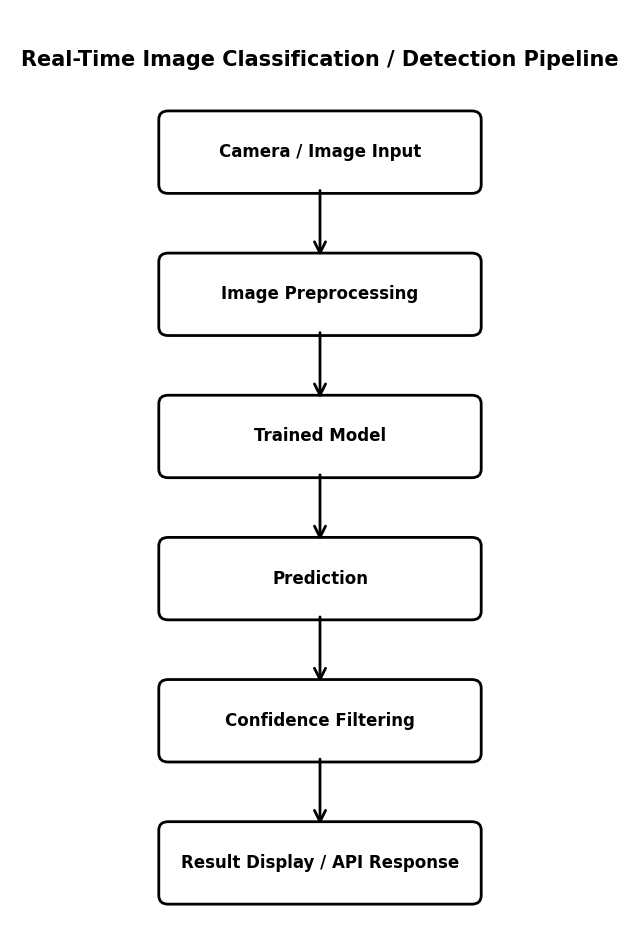

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create figure
fig, ax = plt.subplots(figsize=(8, 12))

# Turn off axes
ax.axis("off")

# Steps in the pipeline
steps = [
    "Camera / Image Input",
    "Image Preprocessing",
    "Trained Model",
    "Prediction",
    "Confidence Filtering",
    "Result Display / API Response"
]

# Y positions for each box
y_positions = [10, 8, 6, 4, 2, 0]

# Draw boxes
for step, y in zip(steps, y_positions):

    box = FancyBboxPatch(
        (2, y - 0.5),       # x, y position
        4,                  # width
        1,                  # height
        boxstyle="round,pad=0.08,rounding_size=0.12",
        edgecolor="black",
        facecolor="white",
        linewidth=2
    )

    ax.add_patch(box)

    ax.text(
        4, y,
        step,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Draw directed arrows
for i in range(len(y_positions) - 1):

    arrow = FancyArrowPatch(
        (4, y_positions[i] - 0.5),      # Start point
        (4, y_positions[i + 1] + 0.5),  # End point
        arrowstyle="->",
        mutation_scale=20,
        linewidth=2,
        color="black"
    )

    ax.add_patch(arrow)

# Title
ax.text(
    4,
    11.3,
    "Real-Time Image Classification / Detection Pipeline",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

# Set limits
ax.set_xlim(0, 8)
ax.set_ylim(-1, 12)

# Save the diagram
plt.savefig(
    "directed_graph_pipeline.png",
    dpi=300,
    bbox_inches="tight"
)

# Display
plt.show()

**Input Layer**

A webcam, mobile camera, uploaded image, or video stream can be used as the input source.

For each incoming frame:

- Capture the image.
- Resize it according to the model requirements.
- Apply the same preprocessing used during training.
- Convert the image into a tensor.

For classification, the project uses 224 × 224 input images, while the detection model uses 640 × 640 images.

**Model Inference Layer**

Two deployment modes can be provided:

**Classification mode**

- Load the trained ResNet-50 model.
- Perform inference on the input image.
- Return the predicted class and confidence score.

**Object-detection mode**

- Load the trained YOLOv8s model.
- Detect objects in the image.
- Return bounding boxes, class labels, and confidence scores.

The reported ResNet-50 achieved 98.90% validation accuracy, while the YOLOv8s augmented experiment achieved 64.36% mAP@50.

**Real-Time Processing**



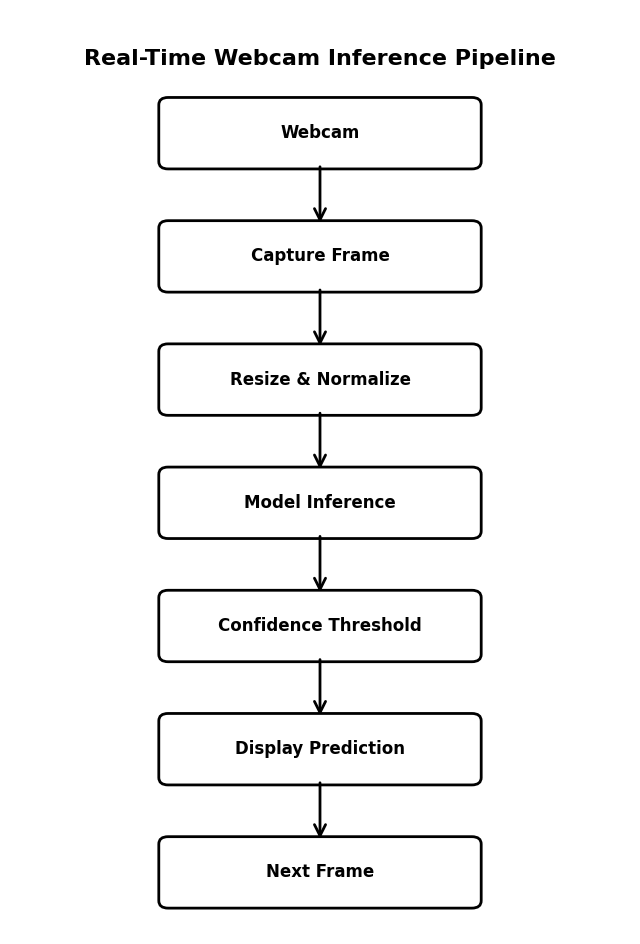

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create figure
fig, ax = plt.subplots(figsize=(8, 12))

# Hide axes
ax.axis("off")

# Pipeline steps
steps = [
    "Webcam",
    "Capture Frame",
    "Resize & Normalize",
    "Model Inference",
    "Confidence Threshold",
    "Display Prediction",
    "Next Frame"
]

# Vertical positions
y_positions = [12, 10, 8, 6, 4, 2, 0]

# Draw boxes
for step, y in zip(steps, y_positions):

    box = FancyBboxPatch(
        (2, y - 0.5),       # Bottom-left position
        4,                  # Width
        1,                  # Height
        boxstyle="round,pad=0.08,rounding_size=0.12",
        edgecolor="black",
        facecolor="white",
        linewidth=2
    )

    ax.add_patch(box)

    # Add text
    ax.text(
        4, y,
        step,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Draw arrows between steps
for i in range(len(y_positions) - 1):

    arrow = FancyArrowPatch(
        (4, y_positions[i] - 0.5),
        (4, y_positions[i + 1] + 0.5),
        arrowstyle="->",
        mutation_scale=20,
        linewidth=2,
        color="black"
    )

    ax.add_patch(arrow)

# Add title
ax.text(
    4,
    13.2,
    "Real-Time Webcam Inference Pipeline",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# Set plot limits
ax.set_xlim(0, 8)
ax.set_ylim(-1, 14)

# Save high-resolution image
plt.savefig(
    "webcam_directed_graph.png",
    dpi=300,
    bbox_inches="tight"
)

# Display graph
plt.show()

A confidence threshold can be used to prevent low-confidence predictions from being displayed as reliable detections.

**Deployment Interface**

A simple Streamlit web application can be developed.For detection, the application can display bounding boxes around detected objects.


**Model Optimization**

Before deployment, the models can be optimized to reduce inference time and resource consumption. Possible approaches include:

- Model quantization
- Pruning
- ONNX conversion
- TensorRT optimization
- Batch-size optimization
- Reduced input resolution where appropriate

This is particularly useful because the current report does not provide a complete inference-latency or deployment-resource comparison.

**Deployment Options**

| Deployment method | Suitable use |
| :--- | :--- |
| **Streamlit** | Demonstration/project web application |
| **FastAPI** | Production-style prediction API |
| **Docker** | Portable deployment |
| **Cloud GPU** | High-volume inference |
| **Edge device** | Camera/IoT applications |
| **ONNX/TensorRT** | Faster optimized inference |

**Monitoring and Continuous Improvement**

After deployment, prediction logs can be collected to identify:

- Frequently misclassified classes
- Low-confidence predictions
- False detections
- Difficult environmental conditions
- Changes in real-world image distribution

These samples can then be added to a future training dataset for periodic model retraining.



**Recommended approach**

- Production inference: Real-time
- Model training: Batch learning
- Model updates: Periodic retraining



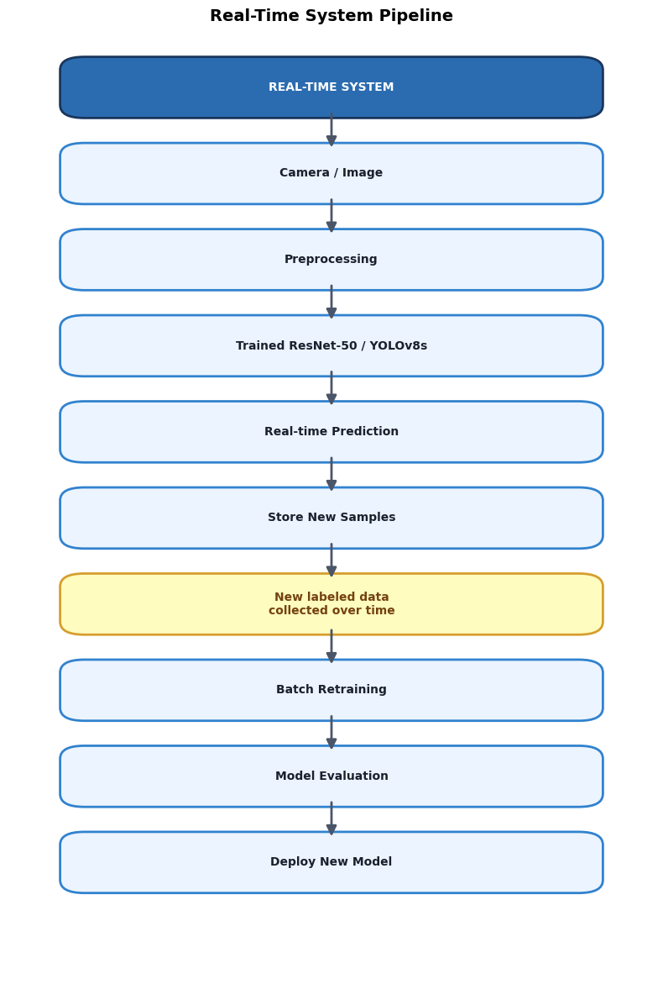

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define the nodes in sequential order
nodes = [
    "REAL-TIME SYSTEM",
    "Camera / Image",
    "Preprocessing",
    "Trained ResNet-50 / YOLOv8s",
    "Real-time Prediction",
    "Store New Samples",
    "New labeled data\ncollected over time",
    "Batch Retraining",
    "Model Evaluation",
    "Deploy New Model",
]

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(-2, 2)
ax.set_ylim(-len(nodes) - 0.5, 0.5)
ax.axis("off")

# Calculate vertical coordinates for each node
y_coords = [-i for i in range(len(nodes))]
box_width = 3.2
box_height = 0.55

# Draw boxes and labels using FancyBboxPatch
for i, (text, y) in enumerate(zip(nodes, y_coords)):
    # Highlight specific header and container nodes with distinct colors
    if i == 0:
        facecolor, edgecolor = "#2B6CB0", "#1A365D"  # Dark Blue
        textcolor = "white"
    elif i == 6:
        facecolor, edgecolor = "#FEFCBF", "#D69E2E"  # Gold/Yellow accent
        textcolor = "#744210"
    else:
        facecolor, edgecolor = "#EBF4FF", "#3182CE"  # Standard Light Blue
        textcolor = "#1A202C"

    # Create rounded box patch
    box = mpatches.FancyBboxPatch(
        (-box_width / 2, y - box_height / 2),
        box_width,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.15",
        mutation_scale=1,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=2,
    )
    ax.add_patch(box)

    # Add centered text inside the box
    ax.text(
        0,
        y,
        text,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=textcolor,
    )

# Draw connecting arrows between boxes
for i in range(len(nodes) - 1):
    y_start = y_coords[i] - (box_height / 2)
    y_end = y_coords[i + 1] + (box_height / 2)

    ax.annotate(
        "",
        xy=(0, y_end),
        xytext=(0, y_start),
        arrowprops=dict(
            arrowstyle="-|>",
            color="#4A5568",
            lw=2,
            mutation_scale=18,
            shrinkA=2,
            shrinkB=2,
        ),
    )

plt.title("Real-Time System Pipeline", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

**Why batch learning fits better**

| Approach | How it would work for your project | Recommendation |
| :--- | :--- | :--- |
| **Batch learning** | Collect new labeled images → retrain model periodically | **Recommended** |
| **Online learning** | Update model continuously as every new labeled image arrives | Not necessary initially |
| **Real-time inference** | Predict immediately from webcam/image input | **Recommended** |



**Learning Strategy for Deployment:**

The proposed system will use batch learning for model training and periodic model updates, while predictions will be performed in real time. The initially trained ResNet-50 and YOLOv8s models will be deployed for real-time inference. New images and low-confidence predictions collected during operation will be periodically reviewed and labeled. These newly labeled samples will be combined with the existing training dataset and used for batch retraining. After evaluating the updated model on a fixed test dataset, the improved model can be deployed as a new production version. This approach provides a controlled model-update process while avoiding continuous online updates that could introduce noisy or incorrectly labeled data into the model.

**Future Enhancements**

1.	**Use Human-Verified Bounding Box Annotations**

The current object-detection dataset uses automatically generated bounding boxes from YOLOv8x, including fallback boxes when no object was detected. Future work should use manually annotated and human-verified bounding boxes to create a more reliable detection dataset and obtain more trustworthy evaluation metrics.

2.	**Improve Performance on Difficult Classes**

Further error analysis can focus on classes that produced relatively more errors, particularly Chain Saw and Gas Pump in the classification experiments. More representative training examples, targeted augmentation, class-specific analysis, and improved feature extraction could be investigated.

3.	**Evaluate Computational Efficiency**

Future work should compare model parameters, memory consumption, inference time, and GPU/CPU resource requirements. This would help determine which model is most appropriate for deployment on resource-constrained devices, since the current report does not provide a complete deployment-oriented comparison.

4. **Expand the Dataset and Number of Categories**
The current project uses ten ImageNet categories. Future versions could include a larger number of categories and more diverse images, allowing the models to be evaluated under more challenging conditions and making the system more applicable to real-world scenarios.








**References**

1. K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In Proceedings of the IEEE conference on computer vision and pattern recognition.

2. Ultralytics, YOLOv8s: https://docs.ultralytics.com/models/yolov8

3. The dataset was given by datamites, https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-1-6/imagenet-subset-10.zip

4. Custom CNN, https://www.tensorflow.org/tutorials/images/cnn,
https://medium.com/@sanjay_dutta/designing-your-own-convolutional-neural-network-cnn-model-a-step-by-step-guide-for-beginners-4e8b57836c81

5. ResNet, https://docs.pytorch.org/vision/0.15/models/resnet.html,
https://www.geeksforgeeks.org/deep-learning/residual-networks-resnet-deep-learning/





